In [1]:
import numpy as np
import os
from scipy.optimize import curve_fit
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
NB = 7
Np = 4*NB*NB*NB

In [2]:
def g2cs(rho):
    """
    calculate the RDF at contact with the Carnahan-Starling EoS and the virial route
    """
    import math
    eta = math.pi/6.0*rho
    g2cs = (1-eta/2.0)/(1-eta)**3
    
    return g2cs

In [3]:
def g2c_liu(rho):
    """
    calculate the RDF at contact with the Carnahan-Starling EoS and the virial route
    """
    import math
    eta = math.pi/6.0*rho
    Z = (1+eta+eta**2-8/13*eta**3-eta**4+1/2*eta**5)/(1-eta)**3
    g2c_liu = (Z-1)/4/eta
    
    return g2c_liu

In [4]:
def g2liu(x, rho):
    """
    calculate the RDF of HS according to Liu's approach.
    """
    import math
    eta = math.pi/6.0*rho
    
    omega = 6.56745+0.721795*eta
    kappa = 1.75879-3.23977*eta+0.449588*eta**2-0.148890*eta**3
    alpha = 0.595157-2.469402*eta-31.99603*eta**2-0.897749*eta**3
    xm = 1.960492-0.240131*eta-3.26102*eta**2+4.08014*eta**3
    gm = 1.072954-1.13263*eta+3.05087*eta**2-5.94853*eta**3
    mu = 0.58236+8.43296*eta-34.52268*eta**2+58.63440*eta**3-35.13525*eta**4
    B = (xm*gm-g2c_liu(rho)*math.exp(mu*(xm-1.0)))/(math.exp(alpha*(xm-1.0))-math.exp(mu*(xm-1.0)))
    A = g2c_liu(rho)-B
    delta = -omega*xm-math.atan((kappa*xm+1.0)/omega/xm)
    C = xm*(gm-1.0)*math.exp(kappa*xm)/math.cos(omega*xm+delta)
    if x < xm:
        g2liu = A/x*math.exp(mu*(x-1.0))+B/x*math.exp(alpha*(x-1.0))
    else:
        g2liu = 1.0+C/x*math.cos(omega*x+delta)*math.exp(-kappa*x)
    
    return g2liu

In [5]:
def g2bou(x, rho):
    """
    calculate the RDF of HS according to Liu's approach.
    """
    import math
    eta = math.pi/6.0*rho

    k0 = -math.log(1.0-eta)+(42.0*eta-39.0*eta**2+9.0*eta**3-2.0*eta**4)/6.0/(1.0-eta)**3
    k1 = (eta**4+6.0*eta**2-12.0*eta)/2.0/(1.0-eta)**3
    k2 = -3.0*eta**2/8.0/(1.0-eta)**2
    k3 = (-eta**4+3.0*eta**2+3.0*eta)/6.0/(1.0-eta)**3
    if x <= math.sqrt(2):
        g2bou = math.exp(k0+k1*x+k2*x**2+k3*x**3)
    else:
        g2bou = None

    return g2bou

In [6]:
def lamPY3(rho, angle):
    import math
    eta = math.pi/6.0*rho
    
    if angle == 0:
        lam = 0.2336*eta+0.1067*eta**2
        
    else:
        if angle == 60:
            a = -1.7568
            b = 1.5779
        elif angle == 90:
            a = -2.7637
            b = 1.8734
        elif angle == 109.5:
            a = -2.9769
            b = 2.4761
        elif angle == 120:
            a = -2.983
            b = 2.6251
        elif angle == 180:
            a = -2.9643
            b = 2.5575
        lam = (1+a*eta+b*eta**2)/(1-eta)**3-1
        
    return lam

In [7]:
def g3PY3(rho, angle):
    import math
    
    g30 = 1.0+lamPY3(rho, angle)
    g3 = g2cs(rho)**2*g30

    return g3

In [8]:
def rLA(rho, angle):
    import math
    
    rLA = 1.0+lamPY3(rho, angle)

    return rLA

In [9]:
def rSA(rho, angle):
    import math
    
    g30 = 1.0+lamPY3(rho, angle)
    rSA = g30/g2cs(rho)

    return rSA

In [10]:
# ------ Autocorrelation time correction ------
def autocorrelation(x):
    x = np.asarray(x)
    x = x-np.mean(x)
    n = len(x)
        
    f = np.fft.fft(np.concatenate([x, np.zeros_like(x)]))
    acf = np.fft.ifft(f * np.conjugate(f))[:n].real
        
    acf /= acf[0]
        
    return acf

# ---- Blocking analysis ----
def blocking(data):
    x = np.array(data, dtype=float)
    n = len(x)
        
    max_level = int(np.floor(np.log2(n)))
    variances = []
    block_sizes = []
        
    for level in range(max_level):
        block_size = 2**level
        n_blocks = n//block_size
        
        if n_blocks < 2:
            break
        
        truncated = x[:n_blocks * block_size]
        blocks = truncated.reshape((n_blocks, block_size))
        block_means = np.mean(blocks, axis=1)
        
        variance = np.var(block_means, ddof=1)
        std_error = np.sqrt(variance/n_blocks)
        
        variances.append(std_error)
        block_sizes.append(block_size)
        
    return np.array(block_sizes), np.array(variances)
    
def AICc(chi2, N, p):
    return chi2 + 2*p + (2*p*(p+1))/(N-p-1)

In [11]:
colors = np.array(["black", "blue", "red", "yellowgreen", "orange", "purple"])
bang = np.array([60, 90, 109.5, 120, 180, 0])
angle = np.array([r"$\theta=60^{\circ}$", r"$\theta=90^{\circ}$", r"$\theta=109.5^{\circ}$", r"$\theta=120^{\circ}$", r"$\theta=180^{\circ}$", "Flexible"])

In [12]:
rho = np.linspace(0.100, 0.900, num=33)
x = np.linspace(0, 0.07, num=100)
r = np.linspace(1.00001, 3.0, num=300)
sg2liu = np.zeros((len(rho),len(r)))
sg2bou = np.zeros((len(rho),len(r)))
g2mean = np.zeros(5)
g2unc = np.zeros(5)
g3mean = np.zeros((5,6))
g3unc = np.zeros((5,6))
lammean = np.zeros((5,6))
lamunc = np.zeros((5,6))
exrdf0 = np.zeros_like(rho)
perr = np.zeros_like(rho)
rdf0_lin = np.zeros_like(rho)
rdf0_quad = np.zeros_like(rho)
chi2_lin = np.zeros_like(rho)
chi2_quad = np.zeros_like(rho)
red_lin = np.zeros_like(rho)
red_quad = np.zeros_like(rho)
popt_lin = np.zeros((len(rho),2))
popt_quad = np.zeros((len(rho),3))
perr_lin = np.zeros((len(rho),2))
perr_quad = np.zeros((len(rho),3))
rdf0_lin_short = np.zeros_like(rho)
rdf0_quad_short = np.zeros_like(rho)
popt_lin_short = np.zeros((len(rho),2))
popt_quad_short = np.zeros((len(rho),3))
perr_lin_short = np.zeros((len(rho),2))
perr_quad_short = np.zeros((len(rho),3))
Z_lin = np.zeros_like(rho)
Z_quad = np.zeros_like(rho)
tcf_popt_lin = np.zeros((len(rho),6,2))
tcf_popt_quad = np.zeros((len(rho),6,3))
tcf_red_lin = np.zeros((len(rho),6))
tcf_red_quad = np.zeros((len(rho),6))
tcf_perr_lin = np.zeros((len(rho),6,2))
tcf_perr_quad = np.zeros((len(rho),6,3))
tcf0_lin = np.zeros((len(rho),6))
tcf0_quad = np.zeros((len(rho),6))
tcf_popt_lin_short = np.zeros((len(rho),6,2))
tcf_popt_quad_short = np.zeros((len(rho),6,3))
tcf_perr_lin_short = np.zeros((len(rho),6,2))
tcf_perr_quad_short = np.zeros((len(rho),6,3))
tcf0_lin_short = np.zeros((len(rho),6))
tcf0_quad_short = np.zeros((len(rho),6))
tcf0_ex = np.zeros((len(rho),6))
tcf0_perr = np.zeros((len(rho),6))
tcf_Z_lin = np.zeros((len(rho),6))
tcf_Z_quad = np.zeros((len(rho),6))
data_rdf1 = []
data_rdf2 = []
data_rdf3 = []
data_rdf4 = []
data_rdf5 = []
data_tcf1 = []
data_tcf2 = []
data_tcf3 = []
data_tcf4 = []
data_tcf5 = []
for l in range(len(rho)):
    os.chdir("C:/Users/HP/OneDrive - Universidad de Concepción/Desktop/MC_tests/enig3/HS-%i/%i-%.3f" %(NB, NB, rho[l]))
    print("WE'RE PROCESSING RHO* = ", rho[l])
    rdf1 = np.loadtxt('rdf_1.dat')
    rdf2 = np.loadtxt('rdf_2.dat')
    rdf3 = np.loadtxt('rdf_3.dat')
    rdf4 = np.loadtxt('rdf_4.dat')
    rdf5 = np.loadtxt('rdf_5.dat')
    tcf1 = np.loadtxt('tcf_1.dat')
    tcf2 = np.loadtxt('tcf_2.dat')
    tcf3 = np.loadtxt('tcf_3.dat')
    tcf4 = np.loadtxt('tcf_4.dat')
    tcf5 = np.loadtxt('tcf_5.dat')
    data_rdf1.append(rdf1)
    data_rdf2.append(rdf2)
    data_rdf3.append(rdf3)
    data_rdf4.append(rdf4)
    data_rdf5.append(rdf5)
    data_tcf1.append(tcf1)
    data_tcf2.append(tcf2)
    data_tcf3.append(tcf3)
    data_tcf4.append(tcf4)
    data_tcf5.append(tcf5)
    conrdf1 = np.loadtxt('conrdf_1.dat')
    conrdf2 = np.loadtxt('conrdf_2.dat')
    conrdf3 = np.loadtxt('conrdf_3.dat')
    conrdf4 = np.loadtxt('conrdf_4.dat')
    conrdf5 = np.loadtxt('conrdf_5.dat')
    contcf1 = np.loadtxt('contcf_1.dat')
    contcf2 = np.loadtxt('contcf_2.dat')
    contcf3 = np.loadtxt('contcf_3.dat')
    contcf4 = np.loadtxt('contcf_4.dat')
    contcf5 = np.loadtxt('contcf_5.dat')
    conrdf = np.loadtxt('con_rdf.dat')
    contcf = np.loadtxt('con_tcf.dat')
    ratio = np.loadtxt('ratio.dat')

    plt.rcParams['text.usetex'] = True
    plt.rcParams.update({'font.size': 15})
    plt.figure(figsize=(5,5))
    plt.tick_params(direction='in')
    plt.plot(ratio[:,0], ratio[:,1], linewidth=0.5, color='red')
    plt.xlim([0, None])
    plt.ylim([0.0001, None])
    plt.xlabel("NC")
    plt.ylabel("Ratio")
    plt.savefig("enig3_ratio_%i-%.3f.pdf" % (Np, rho[l]), format="pdf", bbox_inches="tight")
    plt.close()

    """
    Evaluate noise in datasets:
    """ 
    ind_dr_min = np.zeros(6, dtype=int)
    tv = np.zeros((5,6))
    for i in range(5):
        f = i+1
        Ytcf = np.loadtxt('tcf_%i.dat' %f)
        mask = (Ytcf[:,0] > 1.0) & (Ytcf[:,0] < 3.0)
        for j in range(6):
            data_g3 = Ytcf[:,j+1]
            g = data_g3[mask]
            diff = np.abs(np.diff(g)/g[:-1])
            tv[i,j] = np.mean(diff)*100
    
    for j in range(6):
        if tv[0,j] <= tv[1,j]:
            ind_dr_min[j] = 0
        else:
            ind_dr_min[j] = 1
            
    all_block_sizes = []
    all_std_errors = []
    tcf_all_block_sizes = []
    tcf_all_std_errors = []
    lam_all_block_sizes = []
    lam_all_std_errors = []
    for i in range(5):
        f=i+1
        Yrdf = np.loadtxt('conrdf_%i.dat' %f)
        Ytcf = np.loadtxt('contcf_%i.dat' %f)
        Ylam = np.zeros_like(Ytcf)
        n = len(Yrdf)
        g2mean[i] = np.mean(Yrdf)
        g2std = np.std(Yrdf, ddof=1)
        g2var = np.var(Yrdf, ddof=1)

        rdf_acf = autocorrelation(Yrdf)
        
        tau_int = 0.5
        for t in range(1, n):
            if rdf_acf[t] <= 0:
                break
            tau_int += rdf_acf[t]

        n_eff = n/(2.0*tau_int)
        g2unc[i] = np.sqrt(g2var/n_eff)

        block_sizes, std_errors = blocking(Yrdf)
        all_block_sizes.append(block_sizes)
        all_std_errors.append(std_errors)
        for j in range(6):
            n = len(Ytcf[:,j])
            # g3
            g3mean[i,j] = np.mean(Ytcf[:,j])
            g3std = np.std(Ytcf[:,j], ddof=1)
            g3var = np.var(Ytcf[:,j], ddof=1)
            tcf_acf = autocorrelation(Ytcf[:,j])
            # lam2
            div = np.divide(Ytcf[:,j], Yrdf*Yrdf, out=np.zeros_like(Ytcf[:,j], dtype=float), where=Yrdf!=0)
            Ylam[:,j] = div-1.0
            lammean[i,j] = np.mean(Ylam[:,j])
            lamstd = np.std(Ylam[:,j], ddof=1)
            lamvar = np.var(Ylam[:,j], ddof=1)
            lam_acf = autocorrelation(Ylam[:,j])

            tau_int = 0.5
            for t in range(1, n):
                if tcf_acf[t] <= 0:
                    break
                tau_int += tcf_acf[t]
    
            n_eff = n/(2.0*tau_int)
            g3unc[i,j] = np.sqrt(g3var/n_eff)

            tau_int = 0.5
            for t in range(1, n):
                if lam_acf[t] <= 0:
                    break
                tau_int += lam_acf[t]
    
            n_eff = n/(2.0*tau_int)
            lamunc[i,j] = np.sqrt(lamvar/n_eff)

            tcf_block_sizes, tcf_std_errors = blocking(Ytcf[:,j])
            lam_block_sizes, lam_std_errors = blocking(Ylam[:,j])
            
            tcf_all_block_sizes.append(tcf_block_sizes)
            tcf_all_std_errors.append(tcf_std_errors)
            lam_all_block_sizes.append(lam_block_sizes)
            lam_all_std_errors.append(lam_std_errors)
    
    all_block_sizes = np.array(all_block_sizes)
    all_std_errors = np.array(all_std_errors)
    tcf_all_block_sizes = np.array(tcf_all_block_sizes)
    tcf_all_std_errors = np.array(tcf_all_std_errors)
    lam_all_block_sizes = np.array(lam_all_block_sizes)
    lam_all_std_errors = np.array(lam_all_std_errors)
    
    plt.rcParams.update({'font.size': 15})
    fig, ax = plt.subplots(figsize=(5,5))
    ax.tick_params(direction='in')
    for i in range(5):
        ax.scatter(all_block_sizes[i], all_std_errors[i], marker="s", facecolors=colors[i], edgecolors=colors[i], linewidth=0.4)
        plt.axhline(y=g2unc[i], color=colors[i], linestyle="solid", linewidth=0.4)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.6)
    ax.tick_params(width=0.6)
    ax.set_xlabel("Block size")
    ax.set_ylabel("s.u.")
    ax.set_xscale("log")
    ax.set_title(r"$\rho^{\ast}=%.3f$" %rho[l])
    plt.savefig("enig3_g2su_%i-%.3f.pdf" % (Np, rho[l]), format="pdf", bbox_inches="tight")
    plt.close()

    plt.rcParams.update({'font.size': 15})
    fig, axs = plt.subplots(3, 2, figsize=(10,15))
    axs = axs.flatten()
    for k in range(6):
        for i in range(5):
            axs[k].scatter(tcf_all_block_sizes[6*i+k,:], tcf_all_std_errors[6*i+k,:], marker="s", facecolors=colors[i], edgecolors=colors[i], linewidth=0.4)
            axs[k].axhline(y=g3unc[i,k], color=colors[i], linestyle="solid", linewidth=0.4)
        for axis in ['top','bottom','left','right']:
            axs[k].spines[axis].set_linewidth(0.6)
        axs[k].tick_params(width=0.6)
        axs[k].set_xlabel("Block size")
        axs[k].set_ylabel("s.u.")
        axs[k].set_xscale("log")
        axs[k].set_title(angle[k])
    plt.savefig("enig3_g3su_%i-%.3f.pdf" % (Np, rho[l]), format="pdf", bbox_inches="tight")
    plt.close()

    plt.rcParams.update({'font.size': 15})
    fig, axs = plt.subplots(3, 2, figsize=(10,15))
    axs = axs.flatten()
    for k in range(6):
        for i in range(5):
            axs[k].scatter(lam_all_block_sizes[6*i+k,:], lam_all_std_errors[6*i+k,:], marker="s", facecolors=colors[i], edgecolors=colors[i], linewidth=0.4)
            axs[k].axhline(y=lamunc[i,k], color=colors[i], linestyle="solid", linewidth=0.4)
        for axis in ['top','bottom','left','right']:
            axs[k].spines[axis].set_linewidth(0.6)
        axs[k].tick_params(width=0.6)
        axs[k].set_xlabel("Block size")
        axs[k].set_ylabel("s.u.")
        axs[k].set_xscale("log")
        axs[k].set_title(angle[k])
    plt.savefig("enig3_lamsu_%i-%.3f.pdf" % (Np, rho[l]), format="pdf", bbox_inches="tight")
    plt.close()

    plt.rcParams.update({'font.size': 15})
    fig, ax = plt.subplots(figsize=(5,5))
    ax.tick_params(direction='in')
    ax.scatter(tcf_all_block_sizes[0,:], tcf_all_std_errors[0,:], marker="s", facecolors=colors[0], edgecolors=colors[0], linewidth=0.4)
    ax.scatter(tcf_all_block_sizes[6,:], tcf_all_std_errors[6,:], marker="s", facecolors=colors[1], edgecolors=colors[1], linewidth=0.4)
    ax.scatter(tcf_all_block_sizes[12,:], tcf_all_std_errors[12,:], marker="s", facecolors=colors[2], edgecolors=colors[2], linewidth=0.4)
    ax.scatter(tcf_all_block_sizes[18,:], tcf_all_std_errors[18,:], marker="s", facecolors=colors[3], edgecolors=colors[3], linewidth=0.4)
    ax.scatter(tcf_all_block_sizes[24,:], tcf_all_std_errors[24,:], marker="s", facecolors=colors[4], edgecolors=colors[4], linewidth=0.4)
    ax.axhline(y=g3unc[0,0], color=colors[0], linestyle="solid", linewidth=0.4)
    ax.axhline(y=g3unc[1,0], color=colors[1], linestyle="solid", linewidth=0.4)
    ax.axhline(y=g3unc[2,0], color=colors[2], linestyle="solid", linewidth=0.4)
    ax.axhline(y=g3unc[3,0], color=colors[3], linestyle="solid", linewidth=0.4)
    ax.axhline(y=g3unc[4,0], color=colors[4], linestyle="solid", linewidth=0.4)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.6)
    ax.tick_params(width=0.6)
    ax.set_xlabel("Block size")
    ax.set_ylabel("s.u.")
    ax.set_xscale("log")
    plt.savefig("enig3_g3su60_%i-%.3f.pdf" % (Np, rho[l]), format="pdf", bbox_inches="tight")
    plt.close()

    plt.rcParams.update({'font.size': 15})
    fig, ax = plt.subplots(figsize=(5,5))
    ax.tick_params(direction='in')
    ax.scatter(lam_all_block_sizes[0,:], lam_all_std_errors[0,:], marker="s", facecolors=colors[0], edgecolors=colors[0], linewidth=0.4)
    ax.scatter(lam_all_block_sizes[6,:], lam_all_std_errors[6,:], marker="s", facecolors=colors[1], edgecolors=colors[1], linewidth=0.4)
    ax.scatter(lam_all_block_sizes[12,:], lam_all_std_errors[12,:], marker="s", facecolors=colors[2], edgecolors=colors[2], linewidth=0.4)
    ax.scatter(lam_all_block_sizes[18,:], lam_all_std_errors[18,:], marker="s", facecolors=colors[3], edgecolors=colors[3], linewidth=0.4)
    ax.scatter(lam_all_block_sizes[24,:], lam_all_std_errors[24,:], marker="s", facecolors=colors[4], edgecolors=colors[4], linewidth=0.4)
    ax.axhline(y=lamunc[0,0], color=colors[0], linestyle="solid", linewidth=0.4)
    ax.axhline(y=lamunc[1,0], color=colors[1], linestyle="solid", linewidth=0.4)
    ax.axhline(y=lamunc[2,0], color=colors[2], linestyle="solid", linewidth=0.4)
    ax.axhline(y=lamunc[3,0], color=colors[3], linestyle="solid", linewidth=0.4)
    ax.axhline(y=lamunc[4,0], color=colors[4], linestyle="solid", linewidth=0.4)
    ax.tick_params(width=0.6)
    ax.set_xlabel("Block size")
    ax.set_ylabel("s.u.")
    ax.set_xscale("log")
    plt.savefig("enig3_lamsu60_%i-%.3f.pdf" % (Np, rho[l]), format="pdf", bbox_inches="tight")
    plt.close()

    # --------------------------------------- RDF ---------------------------------------
    xx = conrdf[:,0]
    yy = conrdf[:,1]

    import numpy as np
    from numpy.linalg import inv
    from itertools import combinations

    def fit_linear(x, a, b):
        return a+b*x

    def fit_quadratic(x, a, b, c):
        return a+b*x+c*x**2

    def do_fit(model, x, y, sigma):
        popt, pcov = curve_fit(model, x, y, sigma=sigma, absolute_sigma=True)

        residuals = y-model(x, *popt)
        chi2 = np.sum((residuals/sigma)**2)
        dof = len(x)-len(popt)
        red_chi2 = chi2/dof
    
        return popt, pcov, chi2, red_chi2

    # ----------------------- Original fitting ------------------------------
    popt_lin[l,:], cov_lin, chi2_lin[l], red_lin[l] = do_fit(fit_linear, xx, yy, g2unc)
    popt_quad[l,:], cov_quad, chi2_quad[l], red_quad[l] = do_fit(fit_quadratic, xx, yy, g2unc)
    
    perr_lin[l,:]  = np.sqrt(np.diag(cov_lin))
    perr_quad[l,:] = np.sqrt(np.diag(cov_quad))
    
    rdf0_lin[l] = fit_linear(0.0, *popt_lin[l,:])
    rdf0_quad[l] = fit_quadratic(0.0, *popt_quad[l,:])

    # ----------------------- Stability analysis ---------------------------
    popt_lin_short[l,:], cov_lin_short, chi2_lin_short, red_lin_short = do_fit(fit_linear, xx[:-1], yy[:-1], g2unc[:-1])
    popt_quad_short[l,:], cov_quad_short, chi2_quad_short, red_quad_short = do_fit(fit_quadratic, xx[:-1], yy[:-1], g2unc[:-1])
    
    perr_lin_short[l,:]  = np.sqrt(np.diag(cov_lin_short))
    perr_quad_short[l,:] = np.sqrt(np.diag(cov_quad_short))
    
    rdf0_lin_short[l] = fit_linear(0.0, *popt_lin_short[l,:])
    rdf0_quad_short[l] = fit_quadratic(0.0, *popt_quad_short[l,:])

    Z_lin[l] = abs(popt_lin[l,0]-popt_lin_short[l,0])/perr_lin_short[l,0]
    Z_quad[l] = abs(popt_quad[l,0]-popt_quad_short[l,0])/perr_quad_short[l,0]
    rdf0_AICc_lin = AICc(chi2_lin[l], 5, 2)
    rdf0_AICc_quad = AICc(chi2_quad[l], 5, 3)

    #print("STATISTICAL ANALYSIS FOR RDF:")
    #print("---------------------------------------------------------------")
    if Z_lin[l] < 1.0 and not Z_quad[l] < 1.0:
        #print("LINEAR")
        exrdf0[l] = rdf0_lin[l]
        perr[l] = perr_lin[l,0]

    elif Z_quad[l] < 1.0 and not Z_lin[l] < 1.0:
        #print("QUADRATIC")
        exrdf0[l] = rdf0_quad[l]
        perr[l] = perr_quad[l,0]

    elif Z_lin[l] < 1.0 and Z_quad[l] < 1.0:
        #print("BOTH MODELS ARE STABLE! WE GO TO AIC")
        if abs(rdf0_AICc_lin-rdf0_AICc_quad) < 2:
            #print("LINEAR")
            exrdf0[l] = rdf0_lin[l]
            perr[l] = perr_lin[l,0]
        elif rdf0_AICc_lin<rdf0_AICc_quad:
            #print("LINEAR")
            exrdf0[l] = rdf0_lin[l]
            perr[l] = perr_lin[l,0]
        else:
            #print("QUADRATIC")
            exrdf0[l] = rdf0_quad[l]
            perr[l] = perr_quad[l,0]
    else:
        #print("BOTH MODELS ARE UNSTABLE! WE CHOOSE LINEAR")
        exrdf0[l] = rdf0_lin[l]
        perr[l] = perr_lin[l,0]
            
    x = np.linspace(0, 0.07, num=100)
    srdf_lin = np.zeros(len(x))
    srdf_quad = np.zeros(len(x))
    srdf_lin_short = np.zeros(len(x))
    srdf_quad_short = np.zeros(len(x))
    for j in range(len(x)):
        srdf_lin[j] = fit_linear(x[j], *popt_lin[l,:])
        srdf_quad[j] = fit_quadratic(x[j], *popt_quad[l,:])
        srdf_lin_short[j] = fit_linear(x[j], *popt_lin_short[l,:])
        srdf_quad_short[j] = fit_quadratic(x[j], *popt_quad_short[l,:])
    
    for i in range(len(r)):
        sg2liu[l,i] = g2liu(r[i], rho[l])
        sg2bou[l,i] = g2bou(r[i], rho[l])
    
    plt.rcParams.update({'font.size': 15})
    fig, ax = plt.subplots(figsize=(5,5))
    ax.tick_params(direction='in')
    ax.errorbar(xx, yy, yerr=g2unc, fmt='o', markerfacecolor="black", markeredgecolor="black", markeredgewidth=0.3, capsize=4, elinewidth=0.5, color="black", capthick=0.5, clip_on=False, zorder=10)
    ax.scatter(0.0, g2c_liu(rho[l]), facecolors="white", edgecolors="black", marker="s", label='_nolegend_', linewidth=0.3, clip_on=False, zorder=10)
    ax.scatter(0.0, g2cs(rho[l]), facecolors="white", edgecolors="black", marker="^", label='_nolegend_', linewidth=0.3, clip_on=False, zorder=10)
    ax.errorbar(0.0, rdf0_lin[l], yerr=perr_lin[l,0], fmt='o', markerfacecolor="white", markeredgecolor="blue", markeredgewidth=0.3, capsize=4, elinewidth=0.5, color="blue", capthick=0.5, clip_on=False, zorder=10)
    ax.errorbar(0.0, rdf0_quad[l], yerr=perr_quad[l,0], fmt='o', markerfacecolor="white", markeredgecolor="red", markeredgewidth=0.3, capsize=4, elinewidth=0.5, color="red", capthick=0.5, clip_on=False, zorder=10)
    ax.plot(x, srdf_lin, linestyle="solid", color="blue", linewidth=0.4)
    ax.plot(x, srdf_quad, linestyle="solid", color="red", linewidth=0.4)
    ax.plot(x, srdf_lin_short, linestyle="dotted", color="blue", linewidth=0.4)
    ax.plot(x, srdf_quad_short, linestyle="dotted", color="red", linewidth=0.4)
    ax.annotate(rf'$\chi^2_r$ = {red_lin[l]:.4f}', xy=(0.5, 0.90), xycoords='axes fraction', color="blue", fontsize=12)
    ax.annotate(rf'$\chi^2_r$ = {red_quad[l]:.4f}', xy=(0.5, 0.85), xycoords='axes fraction', color="red", fontsize=12)
    ax.annotate(rf'AICc = {red_lin[l]:.2f}', xy=(0.5, 0.75), xycoords='axes fraction', color="blue", fontsize=12)
    ax.annotate(rf'AICc = {red_quad[l]:.2f}', xy=(0.5, 0.70), xycoords='axes fraction', color="red", fontsize=12)
    ax.set_xlim([0.0, 0.07])
    ax.set_xlabel(r"$\Delta r^{\ast}$")
    ax.set_ylabel(r"$g^{(2)}(k=0)$")
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.6)
    ax.tick_params(width=0.6)
    ax.set_title(r"$\rho^{\ast}=%.3f$" %rho[l])
    plt.savefig("enig3_g2ext_%i-%.3f.pdf" % (Np, rho[l]), format="pdf", bbox_inches="tight")
    plt.close()
    
    plt.rcParams.update({'font.size': 15})
    fig, ax = plt.subplots(figsize=(5,5))
    ax.tick_params(direction='in')
    ax.scatter(rdf3[:,0], rdf3[:,1], facecolors="black", edgecolors="black", linewidth=0.4)
    ax.scatter(1.0, rdf0_lin[-1], facecolors="white", edgecolors="black", linewidth=0.3, clip_on=False, zorder=10)
    ax.scatter(1.0, g2c_liu(rho[l]), facecolors="white", edgecolors="red", marker="s", linewidth=0.4, clip_on=False, zorder=10)
    ax.plot(r, sg2bou[l], linestyle="solid", color="blue", linewidth=0.4)
    ax.plot(r, sg2liu[l], linestyle="solid", color="red", linewidth=0.4)
    plt.axhline(y=1, color="black", linestyle="dotted", linewidth=0.5)
    ax.set_xlim([1.0, 3.0])
    ax.set_ylim([0.0001, None])
    ax.set_xlabel(r"$r^{\ast}$")
    ax.set_ylabel(r"$g^{(2)}(r^{\ast})$")
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(0.6)
    ax.tick_params(width=0.6)
    ax.set_title(r"$\rho^{\ast}=%.3f$" %rho[l])
    plt.savefig("enig3_g2_%i-%.3f.pdf" % (Np, rho[l]), format="pdf", bbox_inches="tight")
    plt.close()
    
    # --------------------------------------- TCF ---------------------------------------
    stcf_lin = np.zeros((6,len(x)))
    stcf_quad = np.zeros((6,len(x)))
    stcf_lin_short = np.zeros((6,len(x)))
    stcf_quad_short = np.zeros((6,len(x)))

    """
    Extrapolation to zero-bin width:
    """
    tcf0_AICc_lin = np.zeros(6)
    tcf0_AICc_quad = np.zeros(6)
    for k in range(6):
        xx = contcf[:,0]
        yy = contcf[:,k+1]/conrdf[:,1]/conrdf[:,1]-1.0
        ssig = lamunc[:,k]

        tcf_popt_lin[l,k,:], tcf_cov_lin, tcf_chi2_lin, tcf_red_lin[l,k] = do_fit(fit_linear, xx[ind_dr_min[k]:], yy[ind_dr_min[k]:], ssig[ind_dr_min[k]:])
        tcf_popt_quad[l,k,:], tcf_cov_quad, tcf_chi2_quad, tcf_red_quad[l,k] = do_fit(fit_quadratic, xx[ind_dr_min[k]:], yy[ind_dr_min[k]:], ssig[ind_dr_min[k]:])
    
        tcf_perr_lin[l,k,:]  = np.sqrt(np.diag(tcf_cov_lin))
        tcf_perr_quad[l,k,:]  = np.sqrt(np.diag(tcf_cov_quad))

        tcf0_lin[l,k] = fit_linear(0.0, *tcf_popt_lin[l,k,:])
        tcf0_quad[l,k] = fit_quadratic(0.0, *tcf_popt_quad[l,k,:])
        
        tcf_popt_lin_short[l,k,:], tcf_cov_lin_short, tcf_chi2_lin_short, tcf_red_lin_short = do_fit(fit_linear, xx[ind_dr_min[k]:-1], yy[ind_dr_min[k]:-1], ssig[ind_dr_min[k]:-1])
        tcf_perr_lin_short[l,k,:]  = np.sqrt(np.diag(tcf_cov_lin_short))
        tcf0_lin_short[l,k] = fit_linear(0.0, *tcf_popt_lin_short[l,k,:])
        tcf_Z_lin[l,k] = abs(tcf_popt_lin[l,k,0]-tcf_popt_lin_short[l,k,0])/tcf_perr_lin_short[l,k,0]
        tcf0_AICc_lin[k] = AICc(tcf_chi2_lin, 5, 2)
        
        if ind_dr_min[k] == 0:
            # ----------------------- Stability analysis ---------------------------
            tcf_popt_quad_short[l,k,:], tcf_cov_quad_short, tcf_chi2_quad_short, tcf_red_quad_short = do_fit(fit_quadratic, xx[ind_dr_min[k]:-1], yy[ind_dr_min[k]:-1], ssig[ind_dr_min[k]:-1])
            
            tcf_perr_quad_short[l,k,:] = np.sqrt(np.diag(tcf_cov_quad_short))
        
            tcf0_quad_short[l,k] = fit_quadratic(0.0, *tcf_popt_quad_short[l,k,:])
            
            tcf_Z_quad[l,k] = abs(tcf_popt_quad[l,k,0]-tcf_popt_quad_short[l,k,0])/tcf_perr_quad_short[l,k,0]
            tcf0_AICc_quad[k] = AICc(tcf_chi2_quad, 5, 3)
            
            if tcf_Z_lin[l,k] < 1.0 and not tcf_Z_quad[l,k] < 1.0:
                tcf0_ex[l,k] = tcf0_lin[l,k]
                tcf0_perr[l,k] = tcf_perr_lin[l,k,0]
    
            elif tcf_Z_quad[l,k] < 1.0 and not tcf_Z_lin[l,k] < 1.0:
                tcf0_ex[l,k] = tcf0_quad[l,k]
                tcf0_perr[l,k] = tcf_perr_quad[l,k,0]
    
            elif tcf_Z_lin[l,k] < 1.0 and tcf_Z_quad[l,k] < 1.0:
                if abs(tcf0_AICc_lin[k]-tcf0_AICc_quad[k]) < 2:
                    tcf0_ex[l,k] = tcf0_lin[l,k]
                    tcf0_perr[l,k] = tcf_perr_lin[l,k,0]
                elif tcf0_AICc_lin[k]<tcf0_AICc_quad[k]:
                    tcf0_ex[l,k] = tcf0_lin[l,k]
                    tcf0_perr[l,k] = tcf_perr_lin[l,k,0]
                else:
                    tcf0_ex[l,k] = tcf0_quad[l,k]
                    tcf0_perr[l,k] = tcf_perr_quad[l,k,0]
            else:
                tcf0_ex[l,k] = tcf0_lin[l,k]
                tcf0_perr[l,k] = tcf_perr_lin[l,k,0]
        else:
            tcf0_ex[l,k] = tcf0_lin[l,k]
            tcf0_perr[l,k] = tcf_perr_lin[l,k,0]
            
        x = np.linspace(0, 0.07, num=100)
        for j in range(len(x)):
            stcf_lin[k,j] = fit_linear(x[j], *tcf_popt_lin[l,k,:])
            stcf_quad[k,j] = fit_quadratic(x[j], *tcf_popt_quad[l,k,:])
            stcf_lin_short[k,j] = fit_linear(x[j], *tcf_popt_lin_short[l,k,:])
            stcf_quad_short[k,j] = fit_quadratic(x[j], *tcf_popt_quad_short[l,k,:])

    plt.rcParams.update({'font.size': 15})
    fig, axs = plt.subplots(3, 2, figsize=(10,15))
    axs = axs.flatten()
    for k in range(6):
        xx = contcf[:,0]
        yy = contcf[:,k+1]/conrdf[:,1]/conrdf[:,1]-1.0
        ssig = lamunc[:,k]
        axs[k].tick_params(direction='in')
        axs[k].errorbar(xx, yy, yerr=ssig, fmt='o', markerfacecolor="black", markeredgecolor="black", markeredgewidth=0.3, capsize=4, elinewidth=0.5, color="black", capthick=0.5, clip_on=False, zorder=10)
        axs[k].errorbar(0.0, tcf0_lin[l,k], yerr=tcf_perr_lin[l,k,0], fmt='o', markerfacecolor="white", markeredgecolor="blue", markeredgewidth=0.3, capsize=4, elinewidth=0.5, color="blue", capthick=0.5, clip_on=False, zorder=10)
        axs[k].errorbar(0.0, tcf0_quad[l,k], yerr=tcf_perr_quad[l,k,0], fmt='o', markerfacecolor="white", markeredgecolor="red", markeredgewidth=0.3, capsize=4, elinewidth=0.5, color="red", capthick=0.5, clip_on=False, zorder=10)
        axs[k].scatter(0.0, lamPY3(rho[l], bang[k]), facecolors="white", edgecolors="black", marker="s", label='_nolegend_', linewidth=0.3, clip_on=False, zorder=10)
        axs[k].plot(x, stcf_lin[k], linestyle="solid", color="blue", linewidth=0.4)
        axs[k].plot(x, stcf_quad[k], linestyle="solid", color="red", linewidth=0.4)
        axs[k].plot(x, stcf_lin_short[k], linestyle="dotted", color="blue", linewidth=0.4)
        axs[k].plot(x, stcf_quad_short[k], linestyle="dotted", color="red", linewidth=0.4)
        axs[k].annotate(rf'$\chi^2_r$ = {tcf_red_lin[l,k]:.4f}', xy=(0.5, 0.90), xycoords='axes fraction', color="blue", fontsize=12)
        axs[k].annotate(rf'$\chi^2_r$ = {tcf_red_quad[l,k]:.4f}', xy=(0.5, 0.85), xycoords='axes fraction', color="red", fontsize=12)
        axs[k].annotate(rf'AICc = {tcf0_AICc_lin[k]:.2f}', xy=(0.5, 0.75), xycoords='axes fraction', color="blue", fontsize=12)
        axs[k].annotate(rf'AICc = {tcf0_AICc_quad[k]:.2f}', xy=(0.5, 0.70), xycoords='axes fraction', color="red", fontsize=12)
        for axis in ['top','bottom','left','right']:
            axs[k].spines[axis].set_linewidth(0.6)
        axs[k].set_xlim([0.0, 0.07])
        axs[k].set_xlabel(r"$\Delta r^{\ast}$")
        axs[k].set_ylabel(r"$\lambda_{2}(k=0)$")
        for axis in ['top','bottom','left','right']:
            axs[k].spines[axis].set_linewidth(0.6)
        axs[k].tick_params(width=0.6)
        axs[k].set_title(angle[k])
    plt.savefig("enig3_lamext_%i-%.3f.pdf" % (Np, rho[l]), format="pdf", bbox_inches="tight")
    plt.close()

    plt.rcParams.update({'font.size': 15})
    fig, axs = plt.subplots(figsize=(5,5))
    for k in range(1):
        xx = contcf[:,k]
        yy = contcf[:,k+1]/conrdf[:,1]/conrdf[:,1]-1
        ssig = lamunc[:,k]
        axs.tick_params(direction='in')
        axs.errorbar(xx, yy, yerr=ssig, fmt='o', markerfacecolor="black", markeredgecolor="black", markeredgewidth=0.3, capsize=4, elinewidth=0.5, color="black", capthick=0.5, clip_on=False, zorder=10)
        axs.errorbar(0.0, tcf0_lin[l,k], yerr=tcf_perr_lin[l,k,0], fmt='o', markerfacecolor="white", markeredgecolor="blue", markeredgewidth=0.3, capsize=4, elinewidth=0.5, color="blue", capthick=0.5, clip_on=False, zorder=10)
        axs.errorbar(0.0, tcf0_quad[l,k], yerr=tcf_perr_quad[l,k,0], fmt='o', markerfacecolor="white", markeredgecolor="red", markeredgewidth=0.3, capsize=4, elinewidth=0.5, color="red", capthick=0.5, clip_on=False, zorder=10)
        axs.scatter(0.0, lamPY3(rho[l], bang[k]), facecolors="white", edgecolors="black", marker="s", label='_nolegend_', linewidth=0.3, clip_on=False, zorder=10)
        axs.plot(x, stcf_lin[k], linestyle="solid", color="blue", linewidth=0.4)
        axs.plot(x, stcf_quad[k], linestyle="solid", color="red", linewidth=0.4)
        axs.plot(x, stcf_lin_short[k], linestyle="dotted", color="blue", linewidth=0.4)
        axs.plot(x, stcf_quad_short[k], linestyle="dotted", color="red", linewidth=0.4)
        axs.annotate(rf'$\chi^2_r$ = {tcf_red_lin[l,k]:.4f}', xy=(0.5, 0.90), xycoords='axes fraction', color="blue", fontsize=12)
        axs.annotate(rf'$\chi^2_r$ = {tcf_red_quad[l,k]:.4f}', xy=(0.5, 0.85), xycoords='axes fraction', color="red", fontsize=12)
        axs.annotate(rf'AICc = {tcf0_AICc_lin[k]:.2f}', xy=(0.5, 0.75), xycoords='axes fraction', color="blue", fontsize=12)
        axs.annotate(rf'AICc = {tcf0_AICc_quad[k]:.2f}', xy=(0.5, 0.70), xycoords='axes fraction', color="red", fontsize=12)
        for axis in ['top','bottom','left','right']:
            axs.spines[axis].set_linewidth(0.6)
        axs.set_xlim([0.0, 0.07])
        axs.set_xlabel(r"$\Delta r^{\ast}$")
        axs.set_ylabel(r"$\lambda_{2}(k=0)$")
        for axis in ['top','bottom','left','right']:
            axs.spines[axis].set_linewidth(0.6)
        axs.tick_params(width=0.6)
    plt.savefig("enig3_lam60ext_%i-%.3f.pdf" % (Np, rho[l]), format="pdf", bbox_inches="tight")
    plt.close()

WE'RE PROCESSING RHO* =  0.1
WE'RE PROCESSING RHO* =  0.125
WE'RE PROCESSING RHO* =  0.15000000000000002
WE'RE PROCESSING RHO* =  0.17500000000000002
WE'RE PROCESSING RHO* =  0.2
WE'RE PROCESSING RHO* =  0.225
WE'RE PROCESSING RHO* =  0.25
WE'RE PROCESSING RHO* =  0.275
WE'RE PROCESSING RHO* =  0.30000000000000004
WE'RE PROCESSING RHO* =  0.325
WE'RE PROCESSING RHO* =  0.35
WE'RE PROCESSING RHO* =  0.375
WE'RE PROCESSING RHO* =  0.4
WE'RE PROCESSING RHO* =  0.42500000000000004
WE'RE PROCESSING RHO* =  0.45000000000000007
WE'RE PROCESSING RHO* =  0.475
WE'RE PROCESSING RHO* =  0.5
WE'RE PROCESSING RHO* =  0.525
WE'RE PROCESSING RHO* =  0.55
WE'RE PROCESSING RHO* =  0.5750000000000001
WE'RE PROCESSING RHO* =  0.6
WE'RE PROCESSING RHO* =  0.625
WE'RE PROCESSING RHO* =  0.65
WE'RE PROCESSING RHO* =  0.675
WE'RE PROCESSING RHO* =  0.7000000000000001
WE'RE PROCESSING RHO* =  0.725
WE'RE PROCESSING RHO* =  0.75
WE'RE PROCESSING RHO* =  0.775
WE'RE PROCESSING RHO* =  0.8
WE'RE PROCESSING RHO* 

In [13]:
os.chdir("C:/Users/HP/OneDrive - Universidad de Concepción/Desktop/MC_tests/enig3/HS-%i" %NB)

In [14]:
barker_r = np.array([
1.0173,1.0512,1.0840,1.1158,1.1467,1.1769,1.2062,1.2349,
1.2629,1.2903,1.3172,1.3435,1.3693,1.3946,1.4195,1.4440,
1.4680,1.4916,1.5149,1.5379,1.5604,1.5827,1.6047,1.6263,
1.6477,1.6688,1.6897,1.7103,1.7306, 1.7507,1.7706,1.7903,1.8097,1.8289,1.8480,1.8668,1.8855,
1.9039,1.9222,1.9404,1.9583,1.9761,1.9937,2.0112,2.0285,
2.0457,2.0628,2.0797,2.0964,2.1131,2.1296,2.1459,2.1622,
2.1783,2.1943,2.2102,2.2260,2.2417,2.2572,2.2727
])

barker_g020 = np.array([
1.3165,1.2797,1.2532,1.2275,1.2051,1.1914,1.1720,1.1629,
1.1456,1.1279,1.1204,1.0968,1.0917,1.0668,1.0682,1.0642,
1.0500,1.0453,1.0464,1.0247,1.0214,1.0117,1.0148,1.0173,
1.0032,1.0106,1.0043,0.9975,0.9931, 0.9816,0.9890,0.9928,0.9760,0.9852,0.9784,0.9760,0.9787,
0.9840,0.9882,0.9869,0.9805,0.9863,0.9868,0.9878,0.9875,
0.9891,0.9895,0.9951,0.9910,0.9904,0.9826,0.9902,0.9957,
0.9921,0.9979,1.0013,0.9958,1.0047,0.9928,1.0004
])

barker_g030 = np.array([
1.5062,1.4432,1.4074,1.3708,1.3335,1.2992,1.2673,1.2278,
1.2110,1.1972,1.1673,1.1364,1.1235,1.1125,1.0950,1.0749,
1.0659,1.0443,1.0350,1.0273,1.0288,1.0105,1.0076,0.9957,
0.9846,0.9747,0.9804,0.9712,0.9733, 0.9664,0.9652,0.9581,0.9592,0.9603,0.9602,0.9612,0.9701,
0.9619,0.9621,0.9701,0.9640,0.9700,0.9714,0.9770,0.9866,
0.9831,0.9816,0.9834,0.9933,0.9898,0.9882,0.9933,0.9969,
0.9964,1.0030,0.9984,1.0021,0.9971,1.0106,0.9987
])

barker_g040 = np.array([
1.7619,1.6732,1.5962,1.5188,1.4546,1.4075,1.3504,1.3054,
1.2697,1.2258,1.1974,1.1651,1.1333,1.1171,1.0897,1.0704,
1.0591,1.0297,1.0208,1.0010,0.9890,0.9745,0.9756,0.9549,
0.9514,0.9507,0.9438,0.9337,0.9360, 0.9350,0.9317,0.9354,0.9292,0.9292,0.9357,0.9350,0.9367,
0.9384,0.9464,0.9452,0.9547,0.9654,0.9720,0.9760,0.9833,
0.9883,0.9918,0.9978,0.9946,1.0036,1.0093,1.0069,0.9999,
1.0112,1.0108,1.0113,1.0146,1.0155,1.0151,1.0171
])

barker_g050 = np.array([
2.0615,1.9392,1.7970,1.6903,1.6008,1.5082,1.4301,1.3606,
1.2967,1.2510,1.2087,1.1601,1.1203,1.0920,1.0617,1.0305,
1.0097,0.9888,0.9685,0.9547,0.9314,0.9302,0.9180,0.9077,
0.9028,0.9010,0.9069,0.8948,0.8925, 0.8955,0.8889,0.8947,0.8893,0.9033,0.9132,0.9210,0.9241,
0.9303,0.9370,0.9518,0.9613,0.9722,0.9823,0.9912,1.0001,
1.0138,1.0178,1.0250,1.0278,1.0265,1.0312,1.0304,1.0387,
1.0362,1.0396,1.0431,1.0369,1.0402,1.0401,1.0431
])

barker_g060 = np.array([
2.4530,2.2415,2.0350,1.8713,1.7216,1.5986,1.4861,1.3891,
1.3112,1.2395,1.1791,1.1245,1.0718,1.0416,0.9999,0.9767,
0.9453,0.9219,0.9010,0.8808,0.8747,0.8567,0.8560,0.8479,
0.8461,0.8384,0.8430,0.8430,0.8472, 0.8527,0.8619,0.8705,0.8749,0.8867,0.9029,0.9100,0.9250,
0.9375,0.9528,0.9676,0.9854,0.9982,1.0147,1.0250,1.0471,
1.0602,1.0649,1.0667,1.0731,1.0738,1.0712,1.0726,1.0771,
1.0735,1.0731,1.0715,1.0656,1.0603,1.0593,1.0559
])

barker_g070 = np.array([
2.9510,2.5863,2.2855,2.0364,1.8191,1.6456,1.5008,1.3856,
1.2767,1.1951,1.1210,1.0514,1.0056,0.9547,0.9214,0.8898,
0.8653,0.8376,0.8202,0.8077,0.7938,0.7956,0.7878,0.7851,
0.7834,0.7851,0.7892,0.7991,0.8065, 0.8146,0.8283,0.8480,0.8615,0.8796,0.9034,0.9238,0.9411,
0.9638,0.9908,1.0094,1.0299,1.0534,1.0769,1.1011,1.1131,
1.1188,1.1297,1.1382,1.1419,1.1340,1.1341,1.1329,1.1188,
1.1140,1.1091,1.0982,1.0911,1.0870,1.0745,1.0608
])

barker_g080 = np.array([
3.6206,3.0149,2.5377,2.1669,1.8826,1.6540,1.4698,1.3200,
1.2017,1.0980,1.0096,0.9491,0.8795,0.8483,0.8091,0.7722,
0.7492,0.7377,0.7255,0.7138,0.7091,0.7113,0.7066,0.7152,
0.7283,0.7381,0.7576,0.7723,0.7928, 0.8176,0.8438,0.8678,0.8934,0.9307,0.9562,0.9810,1.0170,
1.0444,1.0682,1.0869,1.1186,1.1423,1.1660,1.1923,1.2102,
1.2131,1.2146,1.2085,1.2056,1.1900,1.1760,1.1644,1.1506,
1.1320,1.1193,1.1011,1.0898,1.0735,1.0600,1.0450
])

barker_g090 = np.array([
4.5179,3.4892,2.7722,2.2471,1.8767,1.5869,1.3566,1.1837,
1.0512,0.9459,0.8638,0.7915,0.7472,0.7038,0.6756,0.6521,
0.6336,0.6237,0.6186,0.6217,0.6259,0.6339,0.6489,0.6670,
0.6893,0.7223,0.7478,0.7823,0.8195, 0.8655,0.9081,0.9516,0.9942,1.0305,1.0660,1.0992,1.1258,
1.1585,1.1822,1.2060,1.2293,1.2507,1.2721,1.2979,1.3019,
1.3020,1.2878,1.2686,1.2467,1.2217,1.1924,1.1674,1.1422,
1.1129,1.0787,1.0637,1.0300,1.0111,0.9932,0.9729
])

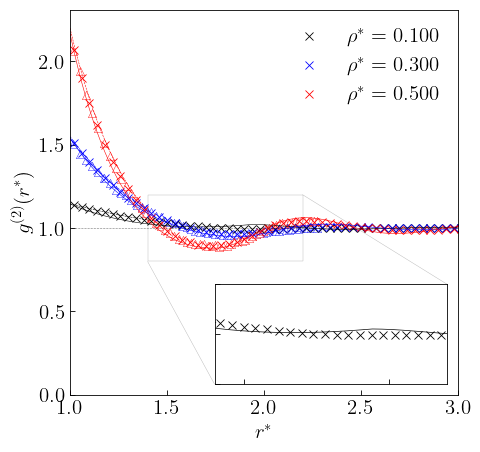

In [15]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import numpy as np

fig, ax = plt.subplots(figsize=(5,5))
extent = (0, 100, 0, 50)

ax.tick_params(direction='in')

ax.scatter(barker_r, barker_g030, marker="^", facecolor="white", edgecolors="blue", linewidth=0.3)
ax.scatter(barker_r, barker_g050, marker="^", facecolor="white", edgecolors="red", linewidth=0.3)
ax.plot(data_rdf3[0][:,0], data_rdf3[0][:,1], marker="x", color="black", markeredgewidth=0.6, linestyle='None', label=r"$\rho^{\ast}=0.100$")
ax.plot(data_rdf3[8][:,0], data_rdf3[8][:,1], marker="x", color="blue", markeredgewidth=0.6, linestyle='None', label=r"$\rho^{\ast}=0.300$")
ax.plot(data_rdf3[16][:,0], data_rdf3[16][:,1], marker="x", color="red", markeredgewidth=0.6, linestyle='None', label=r"$\rho^{\ast}=0.500$")
#ax.scatter(1.0, exrdf0[0], facecolor="black", edgecolors="black", linewidth=0.3,  clip_on=False, zorder=10)
#ax.scatter(1.0, exrdf0[8], facecolor="blue", edgecolors="blue", linewidth=0.3,  clip_on=False, zorder=10)
#ax.scatter(1.0, exrdf0[16], facecolor="red", edgecolors="red", linewidth=0.3,  clip_on=False, zorder=10)
ax.plot(r, sg2liu[0], linestyle="solid", color="black", linewidth=0.4)
ax.plot(r, sg2liu[8], linestyle="solid", color="blue", linewidth=0.4)
ax.plot(r, sg2liu[16], linestyle="solid", color="red", linewidth=0.4)
ax.plot(r, sg2bou[0], linestyle="dashed", color="black", linewidth=0.4)
ax.plot(r, sg2bou[8], linestyle="dashed", color="blue", linewidth=0.4)
ax.plot(r, sg2bou[16], linestyle="dashed", color="red", linewidth=0.4)

axins = zoomed_inset_axes(ax, 1.5, loc=4)
axins.tick_params(direction='in')
axins.plot(data_rdf3[0][:,0], data_rdf3[0][:,1], marker = "x", markeredgewidth=0.6, linestyle='None', color="black", linewidth=0.3)
axins.plot(r, sg2liu[0], linestyle="solid", color="black", linewidth=0.5)
axins.plot(r, sg2bou[0], linestyle="dashed", color="black", linewidth=0.5)

axins.set_xlim(1.4, 2.2)
axins.set_ylim(0.8, 1.2)
ax.axhline(y=1.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([1.0, 3.0])
ax.set_ylim([0.0, None])
ax.set_xlabel(r"$r^{\ast}$")
ax.set_ylabel(r"$g^{(2)}(r^{\ast})$")
plt.xticks(visible=False)
plt.yticks(visible=False)
mark_inset(ax, axins, loc1=3, loc2=1, fc="none", ec="0.7", lw=0.3)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
    axins.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
axins.tick_params(width=0.6)
ax.legend(frameon=False)
plt.savefig("enig3_rdf0_%i_ind1.pdf" % (Np), format="pdf", bbox_inches="tight")
plt.show()

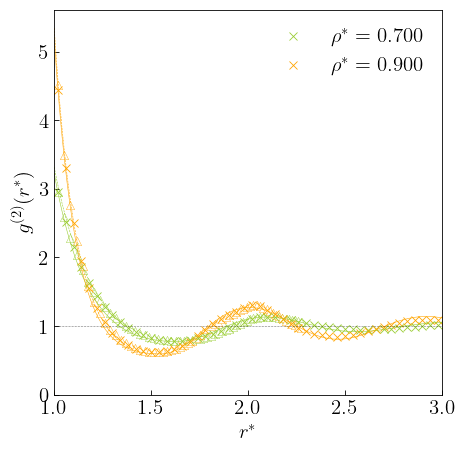

In [16]:
fig, ax = plt.subplots(figsize=(5,5))
extent = (0, 100, 0, 50)

ax.tick_params(direction='in')

ax.scatter(barker_r, barker_g070, marker="^", facecolor="white", edgecolors="yellowgreen", linewidth=0.3)
ax.scatter(barker_r, barker_g090, marker="^", facecolor="white", edgecolors="orange", linewidth=0.3)
ax.plot(data_rdf3[24][:,0], data_rdf3[24][:,1], marker="x", color="yellowgreen", markeredgewidth=0.6, linestyle='None', label=r"$\rho^{\ast}=0.700$")
ax.plot(data_rdf3[32][:,0], data_rdf3[32][:,1], marker="x", color="orange", markeredgewidth=0.6, linestyle='None', label=r"$\rho^{\ast}=0.900$")
#ax.scatter(1.0, exrdf0[24], facecolor="yellowgreen", edgecolors="yellowgreen", linewidth=0.3,  clip_on=False, zorder=10)
#ax.scatter(1.0, exrdf0[32], facecolor="orange", edgecolors="orange", linewidth=0.3,  clip_on=False, zorder=10)
ax.plot(r, sg2liu[24], linestyle="solid", color="yellowgreen", linewidth=0.4)
ax.plot(r, sg2liu[32], linestyle="solid", color="orange", linewidth=0.4)
ax.plot(r, sg2bou[24], linestyle="dashed", color="yellowgreen", linewidth=0.4)
ax.plot(r, sg2bou[32], linestyle="dashed", color="orange", linewidth=0.4)

ax.axhline(y=1.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([1.0, 3.0])
ax.set_ylim([0.0, None])
ax.set_xlabel(r"$r^{\ast}$")
ax.set_ylabel(r"$g^{(2)}(r^{\ast})$")

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
    
ax.tick_params(width=0.6)
ax.legend(frameon=False)
plt.savefig("enig3_rdf0_%i_ind2.pdf" % (Np), format="pdf", bbox_inches="tight")
plt.show()

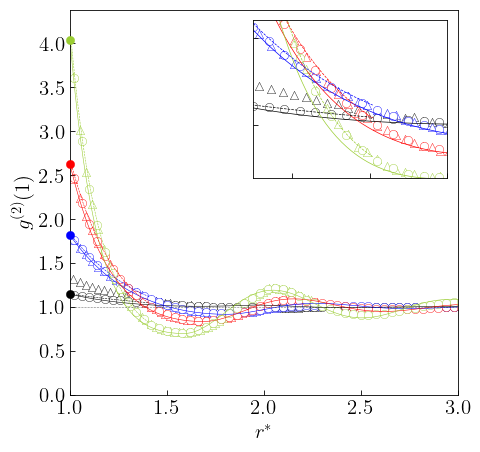

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import numpy as np

fig, ax = plt.subplots(figsize=(5,5))
extent = (0, 100, 0, 50)

ax.tick_params(direction='in')

ax.scatter(barker_r, barker_g020, marker="^", facecolor="white", edgecolors="black", linewidth=0.3)
ax.scatter(barker_r, barker_g040, marker="^", facecolor="white", edgecolors="blue", linewidth=0.3)
ax.scatter(barker_r, barker_g060, marker="^", facecolor="white", edgecolors="red", linewidth=0.3)
ax.scatter(barker_r, barker_g080, marker="^", facecolor="white", edgecolors="yellowgreen", linewidth=0.3)
ax.scatter(data_rdf3[0][:,0], data_rdf3[0][:,1], facecolor="white", edgecolors="black", linewidth=0.3)
ax.scatter(data_rdf3[12][:,0], data_rdf3[12][:,1], facecolor="white", edgecolors="blue", linewidth=0.3)
ax.scatter(data_rdf3[20][:,0], data_rdf3[20][:,1], facecolor="white", edgecolors="red", linewidth=0.3)
ax.scatter(data_rdf3[28][:,0], data_rdf3[28][:,1], facecolor="white", edgecolors="yellowgreen", linewidth=0.3)
ax.scatter(1.0, exrdf0[0], facecolor="black", edgecolors="black", linewidth=0.3,  clip_on=False, zorder=10)
ax.scatter(1.0, exrdf0[12], facecolor="blue", edgecolors="blue", linewidth=0.3,  clip_on=False, zorder=10)
ax.scatter(1.0, exrdf0[20], facecolor="red", edgecolors="red", linewidth=0.3,  clip_on=False, zorder=10)
ax.scatter(1.0, exrdf0[28], facecolor="yellowgreen", edgecolors="yellowgreen", linewidth=0.3,  clip_on=False, zorder=10)
ax.plot(r, sg2liu[0], linestyle="solid", color="black", linewidth=0.4)
ax.plot(r, sg2liu[12], linestyle="solid", color="blue", linewidth=0.4)
ax.plot(r, sg2liu[20], linestyle="solid", color="red", linewidth=0.4)
ax.plot(r, sg2liu[28], linestyle="solid", color="yellowgreen", linewidth=0.4)
ax.plot(r, sg2bou[0], linestyle="dashed", color="black", linewidth=0.4)
ax.plot(r, sg2bou[12], linestyle="dashed", color="blue", linewidth=0.4)
ax.plot(r, sg2bou[20], linestyle="dashed", color="red", linewidth=0.4)
ax.plot(r, sg2bou[28], linestyle="dashed", color="yellowgreen", linewidth=0.4)

axins = zoomed_inset_axes(ax, 2.0, loc=1)
axins.tick_params(direction='in')
axins.scatter(barker_r, barker_g020, marker="^", facecolor="white", edgecolors="black", linewidth=0.3)
axins.scatter(barker_r, barker_g040, marker="^", facecolor="white", edgecolors="blue", linewidth=0.3)
axins.scatter(barker_r, barker_g060, marker="^", facecolor="white", edgecolors="red", linewidth=0.3)
axins.scatter(barker_r, barker_g080, marker="^", facecolor="white", edgecolors="yellowgreen", linewidth=0.3)
axins.scatter(data_rdf3[0][:,0], data_rdf3[0][:,1], facecolor="white", edgecolors="black", linewidth=0.3)
axins.scatter(data_rdf3[12][:,0], data_rdf3[12][:,1], facecolor="white", edgecolors="blue", linewidth=0.3)
axins.scatter(data_rdf3[20][:,0], data_rdf3[20][:,1], facecolor="white", edgecolors="red", linewidth=0.3)
axins.scatter(data_rdf3[28][:,0], data_rdf3[28][:,1], facecolor="white", edgecolors="yellowgreen", linewidth=0.3)
axins.plot(r, sg2liu[0], linestyle="solid", color="black", linewidth=0.5)
axins.plot(r, sg2liu[12], linestyle="solid", color="blue", linewidth=0.5)
axins.plot(r, sg2liu[20], linestyle="solid", color="red", linewidth=0.5)
axins.plot(r, sg2liu[28], linestyle="solid", color="yellowgreen", linewidth=0.5)
axins.plot(r, sg2bou[0], linestyle="dashed", color="black", linewidth=0.5)
axins.plot(r, sg2bou[12], linestyle="dashed", color="blue", linewidth=0.5)
axins.plot(r, sg2bou[20], linestyle="dashed", color="red", linewidth=0.5)
axins.plot(r, sg2bou[28], linestyle="dashed", color="yellowgreen", linewidth=0.5)

axins.set_xlim(1.1, 1.6)
axins.set_ylim(0.7, 1.6)
ax.axhline(y=1.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([1.0, 3.0])
ax.set_ylim([0.0, None])
ax.set_xlabel(r"$r^{\ast}$")
ax.set_ylabel(r"$g^{(2)}(1)$")
plt.xticks(visible=False)
plt.yticks(visible=False)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
    axins.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
axins.tick_params(width=0.6)
#plt.legend(bbox_to_anchor=(1.08, 1), fontsize=12, loc='upper left', frameon=False, borderaxespad=0.)
plt.savefig("enig3_rdf0_%i_ind.pdf" % (Np), format="pdf", bbox_inches="tight")
plt.show()

In [18]:
def g2kol(rho):
    """
    calculate the RDF at contact with the Carnahan-Starling EoS and the virial route
    """
    import math
    eta = math.pi/6.0*rho
    x=eta/(1-eta)
    Zkol = 1+4.0*x+6.0*x**2+2.3647684*x**3-0.8698551*x**4+1.1062803*x**5-1.2105096*x**6
    +1.1356305*x**7-0.5947886*x**8+0.0849805*x**12
    g2kol = (Zkol-1.0)/4.0/eta
    
    return g2kol

In [19]:
srdf0_cs = np.zeros_like(rho)
srdf0_kol = np.zeros_like(rho)
drdf0_cs = np.zeros_like(rho)
drdf0_kol = np.zeros_like(rho)
for i in range(len(rho)):
    srdf0_cs[i] = g2cs(rho[i])
    srdf0_kol[i] = g2kol(rho[i])
    # residuals
    drdf0_cs[i] = (exrdf0[i]-srdf0_cs[i])/perr[i]
    drdf0_kol[i] = (exrdf0[i]-srdf0_kol[i])/perr[i]

In [20]:
drdf0_cs500 = np.array([-1.93444607, -0.02734776, -0.49707925, -1.57913911, -0.13412791,
        0.39428273, -2.09866378, -0.43624244,  0.31522261,  0.22921974,
        1.54857055,  1.0031145 , -0.24583448,  1.90334832, -1.56745487,
        0.41655364, -0.12911891, -0.3854744 ,  2.6787025 ,  1.56573755,
        1.08441718, -0.42467151,  2.20861899,  2.10060682,  2.53936036,
        2.11809363,  1.28289988,  3.71478162,  1.57872813,  2.65255592,
        1.13155543,  0.17069513, -0.74855614])

drdf0_cs864 = np.array([-0.51177338, -1.13475857, -0.59407622,  0.30219007, -0.41283366,
       -1.5819217 ,  1.78576278, -1.8886712 ,  0.90526818,  2.20777843,
        0.20067478,  1.5024866 ,  3.45334146,  2.65437269,  0.54684458,
        0.07717894,  3.79113388,  3.05717614,  3.79699106,  5.13535401,
        3.47408508,  1.85276971,  1.86918194,  3.33980577,  3.07517567,
        4.89430705,  4.18845976,  2.84962882,  1.96916786,  5.20406247,
        2.2560244 ,  2.2805475 ,  2.50334937])

In [21]:
drdf0_kol500 = np.array([-2.01284403, -0.16556101, -0.7147203 , -1.89825762, -0.57232257,
       -0.17929281, -2.84574711, -1.37160415, -0.81257491, -1.137151  ,
       -0.08283656, -0.89383447, -2.41785479, -0.55176845, -4.29058816,
       -2.60784196, -3.39387563, -3.84347919, -0.90770335, -0.30334989,
       -2.39709602, -3.52968456,  0.92242719,  1.39860585,  2.63850436,
        3.44036345,  4.18400282,  9.12720597, 10.13117399, 15.55292943,
       19.2514231 , 25.40448094, 32.59976607])

drdf0_kol864 = np.array([-0.61680768, -1.31751591, -0.87651088, -0.10852444, -0.98340341,
       -2.34808001,  0.80540051, -3.11405535, -0.58301012,  0.40491366,
       -1.94677963, -0.96107004,  0.60656261, -0.59429416, -3.08281283,
       -3.90545527,  1.57800332, -1.4996001 ,  1.36986751,  2.67599848,
        1.18875052, -0.25972215,  0.24038   ,  2.3896218 ,  3.20650531,
        6.5528232 ,  8.09151031,  9.92926999, 13.1569104 , 21.90907986,
       25.6506071 , 35.40789829, 47.24560772])

In [22]:
exrdf0500 = np.array([1.13796549, 1.18498478, 1.2265834 , 1.26906795, 1.32026221,
       1.37163582, 1.41894702, 1.4785542 , 1.53924032, 1.60155205,
       1.6703839 , 1.73945397, 1.81150526, 1.89476274, 1.97232673,
       2.06569962, 2.1602241 , 2.26171738, 2.37626353, 2.49344101,
       2.61481929, 2.74610277, 2.89852106, 3.05345497, 3.22171136,
       3.40047306, 3.59277624, 3.81252748, 4.03423573, 4.28759022,
       4.55373397, 4.84657478, 5.16720714])

exrdf0864 = np.array([1.14306711, 1.1825488 , 1.22668941, 1.27363708, 1.31982167,
       1.3679437 , 1.42664375, 1.47638696, 1.54003014, 1.60453072,
       1.66759313, 1.73975604, 1.81708215, 1.89495882, 1.97608005,
       2.0650344 , 2.17078139, 2.26668129, 2.38160834, 2.50162288,
       2.62240872, 2.75181503, 2.89598041, 3.05479098, 3.22094683,
       3.40670331, 3.59955584, 3.80702208, 4.03396563, 4.29269357,
       4.55615372, 4.85295404, 5.17864912])

In [100]:
perr500 = np.array([0.00328616, 0.00293198, 0.00269799, 0.00251891, 0.0024083 ,
       0.0023389 , 0.00222481, 0.00215555, 0.00213018, 0.00206275,
       0.00199895, 0.00196395, 0.00193598, 0.00191035, 0.0018978 ,
       0.00185844, 0.00184513, 0.00183477, 0.001823  , 0.00350089,
       0.00180355, 0.00181461, 0.00346794, 0.00364176, 0.00350965,
       0.0034924 , 0.00370401, 0.00358372, 0.0036797 , 0.00373528,
       0.00392939, 0.00407245, 0.00437651])

perr864 = np.array([0.0024528 , 0.00221736, 0.00207904, 0.00195715, 0.00184956,
       0.00175099, 0.00169541, 0.00164538, 0.00161422, 0.00156333,
       0.00151859, 0.00151225, 0.00147711, 0.00144371, 0.00142382,
       0.00141129, 0.00272189, 0.00139235, 0.00269374, 0.00266065,
       0.00274755, 0.00266717, 0.00273847, 0.00269055, 0.00264952,
       0.00278435, 0.00275315, 0.00273977, 0.00281294, 0.00288455,
       0.00304344, 0.00310207, 0.003262  ])

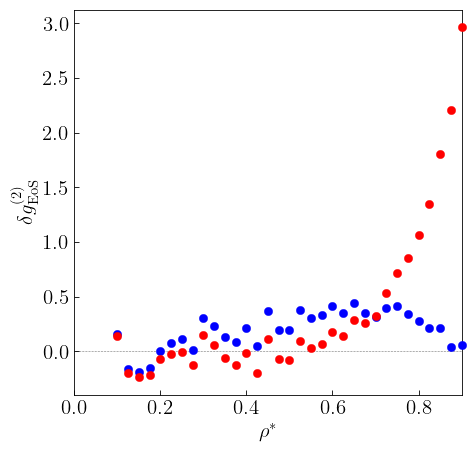

In [101]:
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.scatter(rho, (exrdf0/srdf0_cs-1.0)*100, facecolor="blue", edgecolors="blue", linewidth=0.3, clip_on=False, zorder=10)
ax.scatter(rho, (exrdf0/srdf0_kol-1.0)*100, facecolor="red", edgecolors="red", linewidth=0.3, clip_on=False, zorder=10)
ax.axhline(y=0.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([0.0, 0.9])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$\delta g^{(2)}_{\mathrm{EoS}}$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.savefig("enig3_res_rdf0.pdf", format="pdf", bbox_inches="tight")
plt.show()

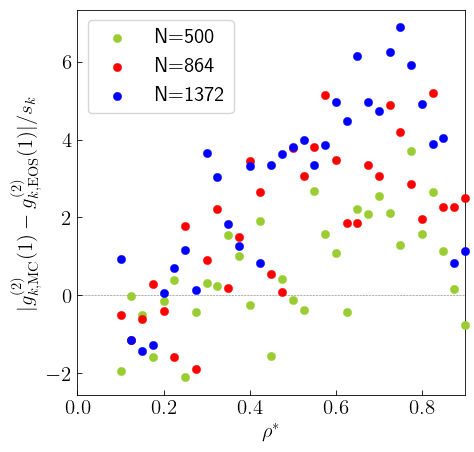

In [102]:
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.scatter(rho, drdf0_cs500, facecolor="yellowgreen", edgecolors="yellowgreen", linewidth=0.3, clip_on=False, zorder=10)
ax.scatter(rho, drdf0_cs864, facecolor="red", edgecolors="red", linewidth=0.3, clip_on=False, zorder=10)
ax.scatter(rho, drdf0_cs, facecolor="blue", edgecolors="blue", linewidth=0.3, clip_on=False, zorder=10)
ax.axhline(y=0.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([0.0, 0.9])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$|g^{(2)}_{k,\mathrm{MC}}(1)-g^{(2)}_{k,\mathrm{EOS}}(1)|/s_{k}$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend(["N=500", "N=864", "N=1372"])
plt.savefig("enig3_resboxcs_rdf0.pdf", format="pdf", bbox_inches="tight")
plt.show()

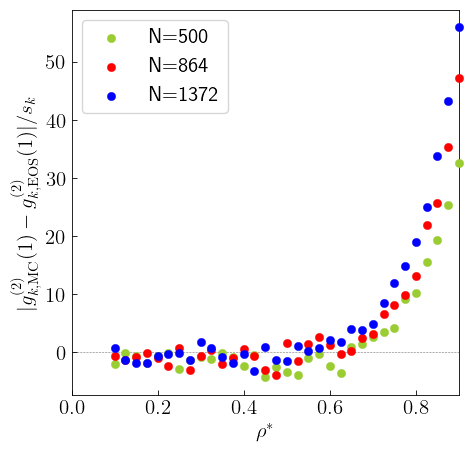

In [103]:
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.scatter(rho, drdf0_kol500, facecolor="yellowgreen", edgecolors="yellowgreen", linewidth=0.3, clip_on=False, zorder=10)
ax.scatter(rho, drdf0_kol864, facecolor="red", edgecolors="red", linewidth=0.3, clip_on=False, zorder=10)
ax.scatter(rho, drdf0_kol, facecolor="blue", edgecolors="blue", linewidth=0.3, clip_on=False, zorder=10)
ax.axhline(y=0.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([0.0, 0.9])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$|g^{(2)}_{k,\mathrm{MC}}(1)-g^{(2)}_{k,\mathrm{EOS}}(1)|/s_{k}$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend(["N=500", "N=864", "N=1372"])
plt.savefig("enig3_resboxkol_rdf0.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [104]:
data_rdf = [data_rdf1, data_rdf2, data_rdf3, data_rdf4, data_rdf5]

In [105]:
r_common = np.linspace(1.0, 3.0, 400)
from scipy.interpolate import PchipInterpolator

g_interp = []

for k in range(len(xx)):  # loop over Δr
    g_interp_k = []
    
    for j in range(len(rho)):  # loop over density
        r_k = data_rdf[k][j][:,0]
        g_k = data_rdf[k][j][:,1]

        interp = PchipInterpolator(r_k, g_k)
        g_interp_k.append(interp(r_common))
    
    g_interp.append(g_interp_k)

In [106]:
rel = np.zeros((len(rho),len(xx),len(r_common)))
k_ref = 0
for j in range(len(rho)):
    for k in range(len(xx)):
        g_ref = g_interp[k_ref][j]
        diff = g_interp[k][j]-g_ref
        rel[j,k,:] = diff/g_ref

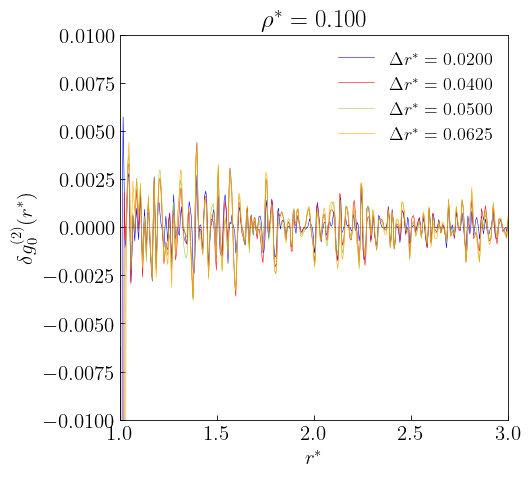

In [107]:
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.plot(r_common, rel[0,1], linestyle="solid", color="blue", linewidth=0.4)
ax.plot(r_common, rel[0,2], linestyle="solid", color="red", linewidth=0.4)
ax.plot(r_common, rel[0,3], linestyle="solid", color="yellowgreen", linewidth=0.4)
ax.plot(r_common, rel[0,4], linestyle="solid", color="orange", linewidth=0.4)
ax.axhline(y=0.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([1.0, 3.0])
ax.set_ylim([-0.01, 0.01])
ax.set_xlabel(r"$r^{\ast}$")
ax.set_ylabel(r"$\delta g^{(2)}_{0}(r^{\ast})$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
ax.set_title(r"$\rho^{\ast}=0.100$")
plt.legend([r"$\Delta r^{\ast}=0.0200$",r"$\Delta r^{\ast}=0.0400$",r"$\Delta r^{\ast}=0.0500$",r"$\Delta r^{\ast}=0.0625$"], frameon=False, fontsize=13)
plt.savefig("enig3_rdf0int_%i-min.pdf" % (Np), format="pdf", bbox_inches="tight")
plt.show()

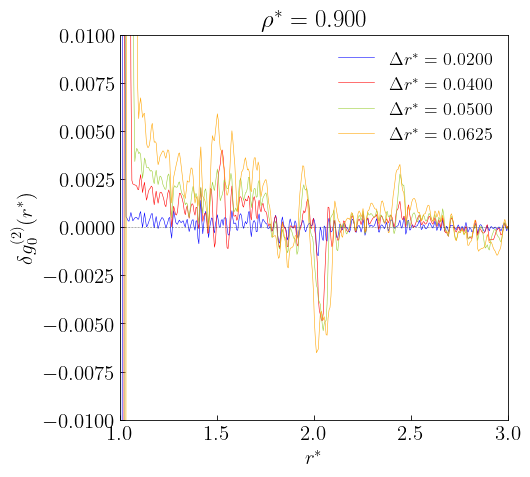

In [108]:
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.plot(r_common, rel[32,1], linestyle="solid", color="blue", linewidth=0.4)
ax.plot(r_common, rel[32,2], linestyle="solid", color="red", linewidth=0.4)
ax.plot(r_common, rel[32,3], linestyle="solid", color="yellowgreen", linewidth=0.4)
ax.plot(r_common, rel[32,4], linestyle="solid", color="orange", linewidth=0.4)
ax.axhline(y=0.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([1.0, 3.0])
ax.set_ylim([-0.01, 0.01])
ax.set_xlabel(r"$r^{\ast}$")
ax.set_ylabel(r"$\delta g^{(2)}_{0}(r^{\ast})$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
ax.set_title(r"$\rho^{\ast}=0.900$")
plt.legend([r"$\Delta r^{\ast}=0.0200$",r"$\Delta r^{\ast}=0.0400$",r"$\Delta r^{\ast}=0.0500$",r"$\Delta r^{\ast}=0.0625$"], frameon=False, fontsize=13)
plt.savefig("enig3_rdf0int_%i-max.pdf" % (Np), format="pdf", bbox_inches="tight")
plt.show()

In [109]:
data_tcf = [data_tcf1, data_tcf2, data_tcf3, data_tcf4, data_tcf5]

In [110]:
data_tcf[0][0][:,0]

array([5.0000e-03, 1.5000e-02, 2.5000e-02, ..., 1.1935e+01, 1.1945e+01,
       1.1955e+01])

In [111]:
g3_interp = []

for k in range(2,len(xx)):
    g3_interp_k = []
    
    for j in range(len(rho)):
        r_k = data_tcf[k][j][:, 0]
        g3_interp_j = []
        
        for b in range(1, len(bang)):
            g3_k = data_tcf[k][j][:, b-1]
            
            interp = PchipInterpolator(r_k, g3_k)
            g3_interp_j.append(interp(r_common))
        
        g3_interp_k.append(g3_interp_j)
    
    g3_interp.append(g3_interp_k)

In [112]:
rel = np.zeros((len(rho), len(bang)-1, len(xx)-2, len(r_common)))

k_ref = 0
for j in range(len(rho)):
    for b in range(len(bang)-1):
        for k in range(len(xx)-2):
            g3_ref = g3_interp[k_ref][j][b]
            diff = g3_interp[k][j][b] - g3_ref
            rel[j,b,k,:] = diff / g3_ref

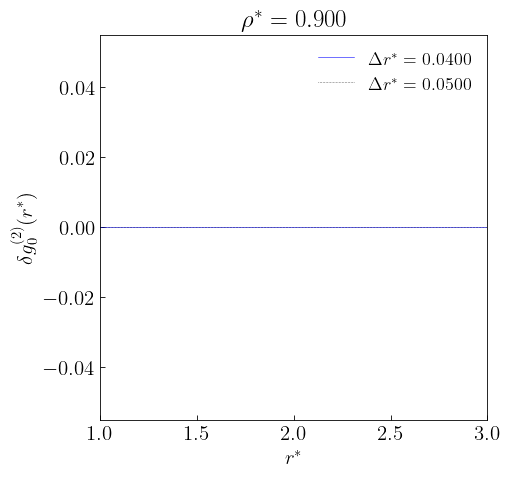

In [113]:
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.plot(r_common, rel[32,0,2], linestyle="solid", color="blue", linewidth=0.4)
#ax.plot(r_common, rel[32,0,3], linestyle="solid", color="red", linewidth=0.4)
#ax.plot(r_common, rel[32,0,4], linestyle="solid", color="yellowgreen", linewidth=0.4)
ax.axhline(y=0.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([1.0, 3.0])
#ax.set_ylim([-0.01, 0.01])
ax.set_xlabel(r"$r^{\ast}$")
ax.set_ylabel(r"$\delta g^{(2)}_{0}(r^{\ast})$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
ax.set_title(r"$\rho^{\ast}=0.900$")
plt.legend([r"$\Delta r^{\ast}=0.0400$",r"$\Delta r^{\ast}=0.0500$",r"$\Delta r^{\ast}=0.0625$"], frameon=False, fontsize=13)
#plt.savefig("enig3_rdf0int_%i-max.pdf" % (Np), format="pdf", bbox_inches="tight")
plt.show()

In [114]:
def g2bou(x, rho):
    """
    calculate the RDF of HS according to Liu's approach.
    """
    import math
    eta = math.pi/6.0*rho

    k0 = -math.log(1.0-eta)+(42.0*eta-39.0*eta**2+9.0*eta**3-2.0*eta**4)/6.0/(1.0-eta)**3
    k1 = (eta**4+6.0*eta**2-12.0*eta)/2.0/(1.0-eta)**3
    k2 = -3.0*eta**2/8.0/(1.0-eta)**2
    k3 = (-eta**4+3.0*eta**2+3.0*eta)/6.0/(1.0-eta)**3
    g2bou = math.exp(k0+k1*x+k2*x**2+k3*x**3)

    return g2bou

In [115]:
import numpy as np
from scipy.optimize import curve_fit

def f1(x, eta):
    k0 = -np.log(1.0-eta)+(42.0*eta-39.0*eta**2+9.0*eta**3-2.0*eta**4)/(6.0*(1.0-eta)**3)
    k1 = (eta**4+6.0*eta**2-12.0*eta)/(2.0*(1.0-eta)**3)
    k2 = -3.0*eta**2/(8.0*(1.0-eta)**2)
    k3 = (-eta**4+3.0*eta**2+3.0*eta)/(6.0*(1.0-eta)**3)

    return np.exp(k0+k1*x+k2*x**2+k3*x**3), k1, k2, k3


def compute_x0(k1, k2, k3):
    return (-2.0*k2 + np.sqrt(4.0*k2**2-12.0*k1*k3))/(6.0*k3)

def f2(x, x0, rho, b2, phi):

    g2_min = g2bou(x0, rho)
    theta0 = phi 
    alpha = -1.0/x0-b2*np.tan(theta0)
    A = (g2_min-1.0)*x0*np.exp(alpha*x0)/np.cos(theta0)

    return 1.0+A/x*np.exp(-alpha*x)*np.cos(b2*(x-x0)+phi)

def f2(x, x0, rho, b2, b3):
    
    g2_min = g2bou(x0, rho)
    alpha = -1.0/x0-b2*np.tan(b2*x0-b3)
    A = (g2_min-1.0)*x0*np.exp(alpha*x0)/np.cos(b2*x0-b3)
    
    return 1.0+A/x*np.exp(-alpha*x)*np.cos(b2*x-b3)

def boz(x, rho, b2, b3):
    eta = np.pi/6.0 * rho

    f1_vals, k1, k2, k3 = f1(x, eta)
    x0 = compute_x0(k1, k2, k3)
    
    x = np.asarray(x)
    y = np.empty_like(x, dtype=float)

    mask = x <= x0

    y[mask] = f1_vals[mask]
    y[~mask] = f2(x[~mask], x0, rho, b2, b3)

    return y

In [116]:
init_guess = [1.0, 1.0]
popt = np.zeros((len(rho),2))
yfit = np.zeros((len(rho),len(r)))
for i in range(len(rho)):
    def boz_fit(x, b2, b3):
        return boz(x, rho[i], b2, b3)
    
    xdata = data_rdf1[i][:,0]
    ydata = data_rdf1[i][:,1]
    mask = (xdata > 1.0) & (xdata < 3.0)
    
    popt[i,:], pcov = curve_fit(
        boz_fit,
        xdata[mask],
        ydata[mask],
        p0 = init_guess
    )
    yfit[i,:] = boz_fit(r, *popt[i,:])
    init_guess = popt[i,:]

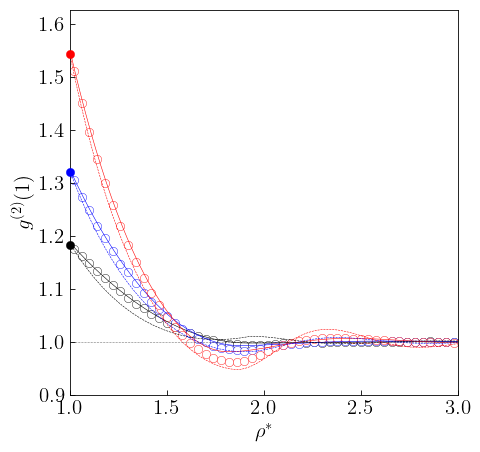

In [117]:
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
#ax.scatter(barker_r, barker_g010, marker="s", facecolor="white", edgecolors="black", linewidth=0.3)
ax.scatter(data_rdf3[1][:,0], data_rdf3[1][:,1], facecolor="white", edgecolors="black", linewidth=0.3)
ax.scatter(data_rdf3[4][:,0], data_rdf3[4][:,1], facecolor="white", edgecolors="blue", linewidth=0.3)
ax.scatter(data_rdf3[8][:,0], data_rdf3[8][:,1], facecolor="white", edgecolors="red", linewidth=0.3)
ax.scatter(1.0, exrdf0[1], facecolor="black", edgecolors="black", linewidth=0.3,  clip_on=False, zorder=10)
ax.scatter(1.0, exrdf0[4], facecolor="blue", edgecolors="blue", linewidth=0.3,  clip_on=False, zorder=10)
ax.scatter(1.0, exrdf0[8], facecolor="red", edgecolors="red", linewidth=0.3,  clip_on=False, zorder=10)
ax.plot(r, yfit[1], linestyle="solid", color="black", linewidth=0.4)
ax.plot(r, yfit[4], linestyle="solid", color="blue", linewidth=0.4)
ax.plot(r, yfit[8], linestyle="solid", color="red", linewidth=0.4)
ax.plot(r, sg2liu[1], linestyle="dashed", color="black", linewidth=0.4)
ax.plot(r, sg2liu[4], linestyle="dashed", color="blue", linewidth=0.4)
ax.plot(r, sg2liu[8], linestyle="dashed", color="red", linewidth=0.4)
ax.axhline(y=1.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([1.0, 3.0])
ax.set_ylim([0.9, None])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$g^{(2)}(1)$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.savefig("enig3_rdf0_%i_ind.pdf" % (Np), format="pdf", bbox_inches="tight")
plt.show()

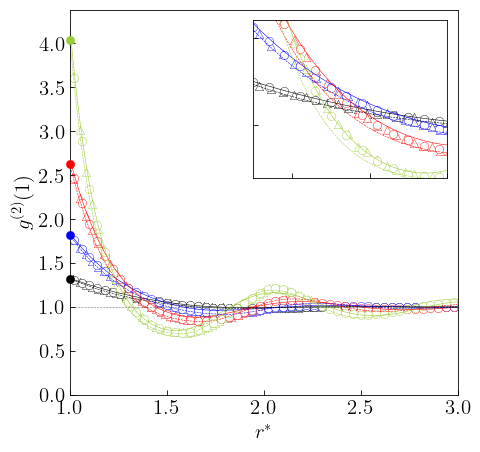

In [118]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
import numpy as np

fig, ax = plt.subplots(figsize=(5,5))
extent = (0, 100, 0, 50)

ax.tick_params(direction='in')

ax.scatter(barker_r, barker_g020, marker="^", facecolor="white", edgecolors="black", linewidth=0.3)
ax.scatter(barker_r, barker_g040, marker="^", facecolor="white", edgecolors="blue", linewidth=0.3)
ax.scatter(barker_r, barker_g060, marker="^", facecolor="white", edgecolors="red", linewidth=0.3)
ax.scatter(barker_r, barker_g080, marker="^", facecolor="white", edgecolors="yellowgreen", linewidth=0.3)
ax.scatter(data_rdf3[4][:,0], data_rdf3[4][:,1], facecolor="white", edgecolors="black", linewidth=0.3)
ax.scatter(data_rdf3[12][:,0], data_rdf3[12][:,1], facecolor="white", edgecolors="blue", linewidth=0.3)
ax.scatter(data_rdf3[20][:,0], data_rdf3[20][:,1], facecolor="white", edgecolors="red", linewidth=0.3)
ax.scatter(data_rdf3[28][:,0], data_rdf3[28][:,1], facecolor="white", edgecolors="yellowgreen", linewidth=0.3)
ax.scatter(1.0, exrdf0[4], facecolor="black", edgecolors="black", linewidth=0.3,  clip_on=False, zorder=10)
ax.scatter(1.0, exrdf0[12], facecolor="blue", edgecolors="blue", linewidth=0.3,  clip_on=False, zorder=10)
ax.scatter(1.0, exrdf0[20], facecolor="red", edgecolors="red", linewidth=0.3,  clip_on=False, zorder=10)
ax.scatter(1.0, exrdf0[28], facecolor="yellowgreen", edgecolors="yellowgreen", linewidth=0.3,  clip_on=False, zorder=10)
ax.plot(r, yfit[4], linestyle="solid", color="black", linewidth=0.4)
ax.plot(r, yfit[12], linestyle="solid", color="blue", linewidth=0.4)
ax.plot(r, yfit[20], linestyle="solid", color="red", linewidth=0.4)
ax.plot(r, yfit[28], linestyle="solid", color="yellowgreen", linewidth=0.4)
ax.plot(r, sg2liu[4], linestyle="dashed", color="black", linewidth=0.4)
ax.plot(r, sg2liu[12], linestyle="dashed", color="blue", linewidth=0.4)
ax.plot(r, sg2liu[20], linestyle="dashed", color="red", linewidth=0.4)
ax.plot(r, sg2liu[28], linestyle="dashed", color="yellowgreen", linewidth=0.4)

axins = zoomed_inset_axes(ax, 2.0, loc=1)
axins.tick_params(direction='in')
axins.scatter(barker_r, barker_g020, marker="^", facecolor="white", edgecolors="black", linewidth=0.3)
axins.scatter(barker_r, barker_g040, marker="^", facecolor="white", edgecolors="blue", linewidth=0.3)
axins.scatter(barker_r, barker_g060, marker="^", facecolor="white", edgecolors="red", linewidth=0.3)
axins.scatter(barker_r, barker_g080, marker="^", facecolor="white", edgecolors="yellowgreen", linewidth=0.3)
axins.scatter(data_rdf3[4][:,0], data_rdf3[4][:,1], facecolor="white", edgecolors="black", linewidth=0.3)
axins.scatter(data_rdf3[12][:,0], data_rdf3[12][:,1], facecolor="white", edgecolors="blue", linewidth=0.3)
axins.scatter(data_rdf3[20][:,0], data_rdf3[20][:,1], facecolor="white", edgecolors="red", linewidth=0.3)
axins.scatter(data_rdf3[28][:,0], data_rdf3[28][:,1], facecolor="white", edgecolors="yellowgreen", linewidth=0.3)
axins.plot(r, yfit[4], linestyle="solid", color="black", linewidth=0.4)
axins.plot(r, yfit[12], linestyle="solid", color="blue", linewidth=0.4)
axins.plot(r, yfit[20], linestyle="solid", color="red", linewidth=0.4)
axins.plot(r, yfit[28], linestyle="solid", color="yellowgreen", linewidth=0.4)
axins.plot(r, sg2liu[4], linestyle="dashed", color="black", linewidth=0.4)
axins.plot(r, sg2liu[12], linestyle="dashed", color="blue", linewidth=0.4)
axins.plot(r, sg2liu[20], linestyle="dashed", color="red", linewidth=0.4)
axins.plot(r, sg2liu[28], linestyle="dashed", color="yellowgreen", linewidth=0.4)

axins.set_xlim(1.1, 1.6)
axins.set_ylim(0.7, 1.6)
ax.axhline(y=1.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([1.0, 3.0])
ax.set_ylim([0.0, None])
ax.set_xlabel(r"$r^{\ast}$")
ax.set_ylabel(r"$g^{(2)}(1)$")
plt.xticks(visible=False)
plt.yticks(visible=False)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
    axins.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
axins.tick_params(width=0.6)
#plt.legend(bbox_to_anchor=(1.08, 1), fontsize=12, loc='upper left', frameon=False, borderaxespad=0.)
plt.savefig("enig3_rdf0_%i_ind.pdf" % (Np), format="pdf", bbox_inches="tight")
plt.show()

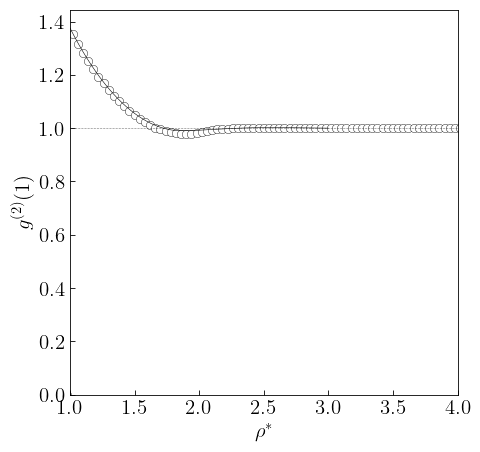

In [119]:
import numpy as np
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.scatter(data_rdf3[5][:,0], data_rdf3[5][:,1], facecolor="white", edgecolors="black", linewidth=0.3)
ax.plot(r, yfit[5], linestyle="solid", color="black", linewidth=0.4)
ax.axhline(y=1.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([1.0, 4.0])
ax.set_ylim([0.0, None])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$g^{(2)}(1)$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.savefig("enig3_newrdf0.pdf", format="pdf", bbox_inches="tight")
plt.show()

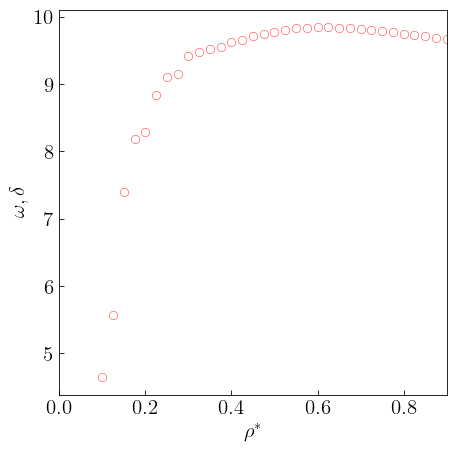

In [120]:
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
#ax.scatter(rho, popt[:,0], facecolor="white", edgecolors="blue", linewidth=0.3)
ax.scatter(rho, popt[:,1], facecolor="white", edgecolors="red", linewidth=0.3)
ax.set_xlim([0.0, 0.9])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$\omega,\delta$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.show()

In [121]:
x = rho
xfit = np.linspace(0.0, 0.9, 200)
y = popt[:,0]

def model(x, a, b, c):
    import math
    x = x*math.pi/6.0
    return x*(a+b*x)/(1.0+c*x)
    
init_guess = [1.0, 1.0, 1.0]
params, _ = curve_fit(model, x, y, p0=init_guess)
print(params)

res_omg = (model(x, *params)/y-1.0)*100
aapd = np.mean(abs(model(x, *params)/y-1.0)*100)
print(aapd)
y_omg = model(xfit, *params)

[ 69.71024832 -22.57532283   7.37494226]
3.6946336407312512


In [122]:
x = rho
y = popt[:,1]

params, _ = curve_fit(model, x, y, p0=init_guess)
print(params)

res_del = (model(x, *params)/y-1.0)*100
aapd = np.mean(abs(model(x, *params)/y-1.0)*100)
print(aapd)
y_del = model(xfit, *params)

[ 173.7610091  -111.7926691    10.69917022]
2.9050000549149173


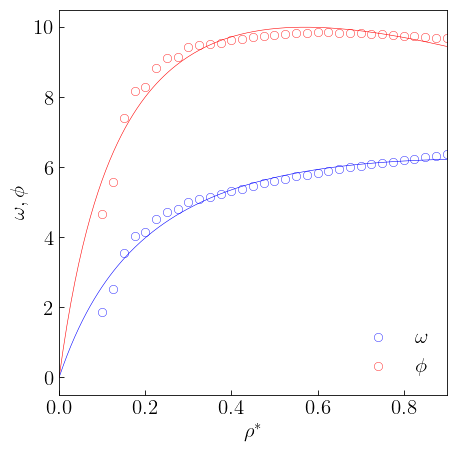

In [123]:
import numpy as np
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.scatter(rho, popt[:,0], facecolor="white", edgecolors="blue", linewidth=0.3)
ax.scatter(rho, popt[:,1], facecolor="white", edgecolors="red", linewidth=0.3)
ax.plot(xfit, y_omg, linestyle="solid", color="blue", linewidth=0.4)
ax.plot(xfit, y_del, linestyle="solid", color="red", linewidth=0.4)
ax.set_xlim([0.0, 0.9])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$\omega,\phi$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend([r"$\omega$", r"$\phi$"], frameon=False)
plt.savefig("enig3_rdf0_params.pdf", format="pdf", bbox_inches="tight")
plt.show()

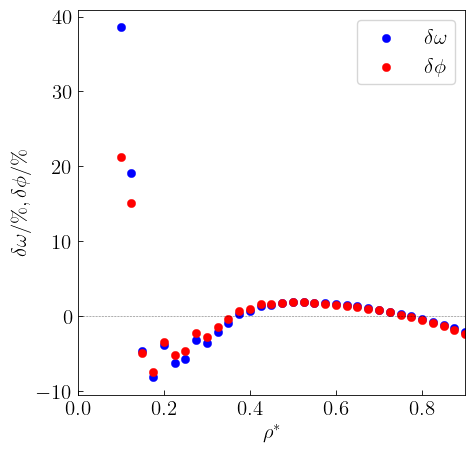

In [124]:
import numpy as np
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.scatter(rho, res_omg, facecolor="blue", edgecolors="blue", linewidth=0.3)
ax.scatter(rho, res_del, facecolor="red", edgecolors="red", linewidth=0.3)
ax.axhline(y=0.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([0.0, 0.9])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$\delta\omega/\%,\delta\phi/\%$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend([r"$\delta\omega$", r"$\delta\phi$"])
plt.savefig("enig3_rdf0_res.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [125]:
def g2ugvm(rho, x):
    import math
    eta = math.pi/6.0*rho
    
    k0 = -math.log(1.0-eta)+(42.0*eta-39.0*eta**2+9.0*eta**3-2.0*eta**4)/6.0/(1.0-eta)**3
    k1 = (eta**4+6.0*eta**2-12.0*eta)/2.0/(1.0-eta)**3
    k2 = -3.0*eta**2/8.0/(1.0-eta)**2
    k3 = (-eta**4+3.0*eta**2+3.0*eta)/6.0/(1.0-eta)**3
    omega = eta*(69.5657463-22.56509497*eta)/(1.0+7.3516894*eta)
    phi = eta*(173.26986329-111.58509692*eta)/(1.0+10.65619151*eta)
    # compute minimum
    x0 = (-2.0*k2+math.sqrt(4.0*k2**2-12.0*k1*k3))/(6.0*k3)
    g2_min = math.exp(k0+k1*x0+k2*x0**2+k3*x0**3)
    
    if x <= x0:
        g2 = math.exp(k0+k1*x+k2*x**2+k3*x**3)
    else:
        alpha = -1.0/x0-omega*math.tan(omega*x0-phi)
        A = (g2_min-1.0)*x0*math.exp(alpha*x0)/np.cos(omega*x0-phi)
        g2 = 1.0+A/x*math.exp(-alpha*x)*math.cos(omega*x-phi)

    return g2

In [126]:
sg2ugvm = np.zeros((len(rho),len(r)))
for i in range(len(rho)):
    for j in range(len(r)):
        sg2ugvm[i,j] = g2ugvm(rho[i],r[j])

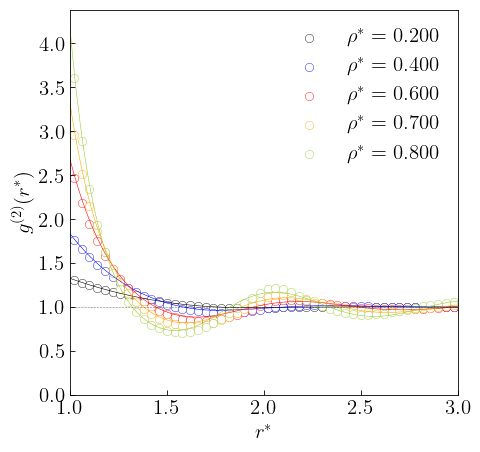

In [127]:
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
#ax.scatter(barker_r, barker_g010, marker="s", facecolor="white", edgecolors="black", linewidth=0.3)
ax.scatter(data_rdf3[4][:,0], data_rdf3[4][:,1], facecolor="white", edgecolors="black", linewidth=0.3)
ax.scatter(data_rdf3[12][:,0], data_rdf3[12][:,1], facecolor="white", edgecolors="blue", linewidth=0.3)
ax.scatter(data_rdf3[20][:,0], data_rdf3[20][:,1], facecolor="white", edgecolors="red", linewidth=0.3)
ax.scatter(data_rdf3[24][:,0], data_rdf3[24][:,1], facecolor="white", edgecolors="orange", linewidth=0.3)
ax.scatter(data_rdf3[28][:,0], data_rdf3[28][:,1], facecolor="white", edgecolors="yellowgreen", linewidth=0.3)
ax.plot(r, sg2ugvm[4], linestyle="solid", color="black", linewidth=0.4)
ax.plot(r, sg2ugvm[12], linestyle="solid", color="blue", linewidth=0.4)
ax.plot(r, sg2ugvm[20], linestyle="solid", color="red", linewidth=0.4)
ax.plot(r, sg2ugvm[24], linestyle="solid", color="orange", linewidth=0.4)
ax.plot(r, sg2ugvm[28], linestyle="solid", color="yellowgreen", linewidth=0.4)
ax.axhline(y=1.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([1.0, 3.0])
ax.set_ylim([0.0, None])
ax.set_xlabel(r"$r^{\ast}$")
ax.set_ylabel(r"$g^{(2)}(r^{\ast})$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend([r"$\rho^{\ast}=0.200$",r"$\rho^{\ast}=0.400$",r"$\rho^{\ast}=0.600$",r"$\rho^{\ast}=0.700$",r"$\rho^{\ast}=0.800$"], frameon=False)
plt.savefig("enig3_rdf0ugvm_%i.pdf" % (Np), format="pdf", bbox_inches="tight")
plt.show()

In [128]:
# --------------------------------------------------- TCFs --------------------------------------------------------

In [129]:
# with minimum fixed
def f1(x, x0, g30, k2, k3):
    
    k1 = -x0*(3.0*x0*k3+2.0*k2)
    k0 = np.log(g30)-(k1+k2+k3)
    
    return np.exp(k0+k1*x+k2*x**2+k3*x**3)

def f2(x, x0, g30, k2, k3, b2, phi):
    
    g_min = f1(x0, x0, g30, k2, k3)
    
    alpha = -1.0/x0-b2*np.tan(phi)
    A = (g_min-1.0)*x0*np.exp(alpha*x0)/np.cos(phi)
    
    return 1.0+A/x*np.exp(-alpha*x)*np.cos(b2*(x-x0)+phi)

def fit_g3(x, k2, k3, b2, phi, x0, g30):
    
    x = np.asarray(x)
    y = np.empty_like(x, dtype=float)

    mask = x <= x0

    y[mask] = f1(x[mask], x0, g30, k2, k3)
    y[~mask] = f2(x[~mask], x0, g30, k2, k3, b2, phi)

    return y

def fit_g3(x, x0, k2, k3, b2, phi, g30):
    
    x = np.asarray(x)
    y = np.empty_like(x, dtype=float)

    mask = x <= x0

    y[mask] = f1(x[mask], x0, g30, k2, k3)
    y[~mask] = f2(x[~mask], x0, g30, k2, k3, b2, phi)

    return y

In [130]:
yfit = np.zeros((len(rho)-8,6,len(r)))
popt = np.zeros((len(rho)-8,6,5))
for i in range(8,len(rho)):
    rho_index = i
    print("We are processing rho* =", np.round(rho[rho_index],3))
    for j in range(6):
        ang_index = j
        x_data = data_tcf3[rho_index][:,0]        
        g_data = data_tcf3[rho_index][:,ang_index+1]
        mask = (x_data > 1.0) & (x_data < 3.0)
        x0 = x_data[mask][np.argmin(g_data[mask])]
        if i == 8:
            init_val = [x0, 1.0, 1.0, 5.0, 0.0]
        else:
            init_val = popt[i-9,j]
        g30s = (tcf0_ex[rho_index]+1.0)*exrdf0[rho_index]**2
        g30_val = g30s[ang_index]
        popt[i-8,j,:], pcov = curve_fit(
            lambda x, x0, k2, k3, b2, phi: fit_g3(x, x0, k2, k3, b2, phi, g30_val),
            x_data[mask],
            g_data[mask],
            p0 = init_val,
            maxfev=50000
            )
        yfit[i-8,j,:] = fit_g3(r, *popt[i-8,j,:], g30_val)

We are processing rho* = 0.3
We are processing rho* = 0.325
We are processing rho* = 0.35
We are processing rho* = 0.375
We are processing rho* = 0.4
We are processing rho* = 0.425
We are processing rho* = 0.45
We are processing rho* = 0.475
We are processing rho* = 0.5
We are processing rho* = 0.525
We are processing rho* = 0.55
We are processing rho* = 0.575
We are processing rho* = 0.6


C:\Users\HP\AppData\Local\Temp\ipykernel_5000\1744833467.py:14: RuntimeWarning: overflow encountered in exp
  A = (g_min-1.0)*x0*np.exp(alpha*x0)/np.cos(phi)
C:\Users\HP\AppData\Local\Temp\ipykernel_5000\1744833467.py:16: RuntimeWarning: invalid value encountered in multiply
  return 1.0+A/x*np.exp(-alpha*x)*np.cos(b2*(x-x0)+phi)
C:\Users\HP\AppData\Local\Temp\ipykernel_5000\1744833467.py:16: RuntimeWarning: overflow encountered in exp
  return 1.0+A/x*np.exp(-alpha*x)*np.cos(b2*(x-x0)+phi)


We are processing rho* = 0.625
We are processing rho* = 0.65
We are processing rho* = 0.675
We are processing rho* = 0.7
We are processing rho* = 0.725
We are processing rho* = 0.75
We are processing rho* = 0.775
We are processing rho* = 0.8
We are processing rho* = 0.825
We are processing rho* = 0.85
We are processing rho* = 0.875
We are processing rho* = 0.9


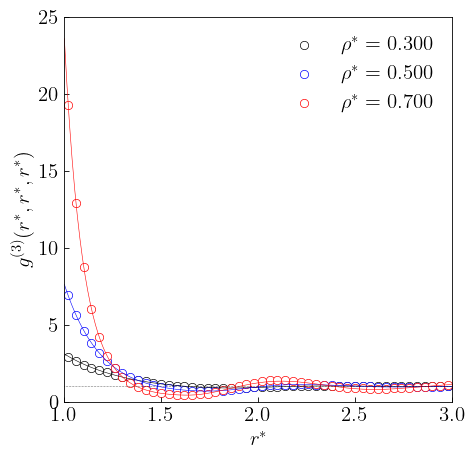

In [131]:
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.scatter(data_tcf3[8][:,0], data_tcf3[8][:,1], facecolor="white", edgecolors="black", linewidth=0.5)
ax.scatter(data_tcf3[16][:,0], data_tcf3[16][:,1], facecolor="white", edgecolors="blue", linewidth=0.5)
ax.scatter(data_tcf3[24][:,0], data_tcf3[24][:,1], facecolor="white", edgecolors="red", linewidth=0.5)
ax.plot(r, yfit[0,0], linestyle="solid", color="black", linewidth=0.4)
ax.plot(r, yfit[8,0], linestyle="solid", color="blue", linewidth=0.4)
ax.plot(r, yfit[16,0], linestyle="solid", color="red", linewidth=0.4)
ax.axhline(y=1.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([1.0, 3.0])
ax.set_ylim([0, 25])
ax.set_xlabel(r"$r^{\ast}$")
ax.set_ylabel(r"$g^{(3)}(r^{\ast},r^{\ast},r^{\ast})$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend([r"$\rho^{\ast}=0.300$", r"$\rho^{\ast}=0.500$", r"$\rho^{\ast}=0.700$"], frameon=False)
plt.savefig("enig3_tcf_%i_%.1f.pdf" % (Np, bang[0]), format="pdf", bbox_inches="tight")
plt.show()

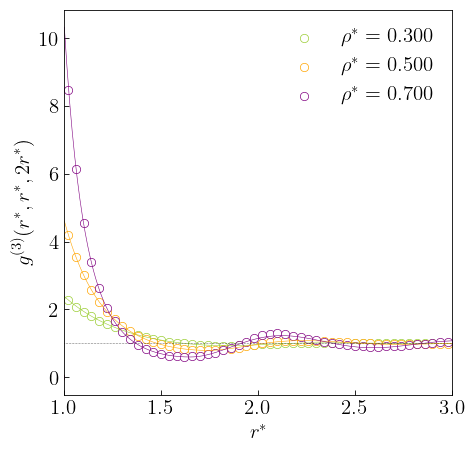

In [132]:
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.scatter(data_tcf3[8][:,0], data_tcf3[8][:,5], facecolor="white", edgecolors="yellowgreen", linewidth=0.5)
ax.scatter(data_tcf3[16][:,0], data_tcf3[16][:,5], facecolor="white", edgecolors="orange", linewidth=0.5)
ax.scatter(data_tcf3[24][:,0], data_tcf3[24][:,5], facecolor="white", edgecolors="purple", linewidth=0.5)
ax.plot(r, yfit[0,4], linestyle="solid", color="yellowgreen", linewidth=0.4)
ax.plot(r, yfit[8,4], linestyle="solid", color="orange", linewidth=0.4)
ax.plot(r, yfit[16,4], linestyle="solid", color="purple", linewidth=0.4)
ax.axhline(y=1.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([1.0, 3.0])
#ax.set_ylim([0, 25])
ax.set_xlabel(r"$r^{\ast}$")
ax.set_ylabel(r"$g^{(3)}(r^{\ast},r^{\ast},2r^{\ast})$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend([r"$\rho^{\ast}=0.300$", r"$\rho^{\ast}=0.500$", r"$\rho^{\ast}=0.700$"], frameon=False)
plt.savefig("enig3_tcf_%i_%.1f.pdf" % (Np, bang[4]), format="pdf", bbox_inches="tight")
plt.show()

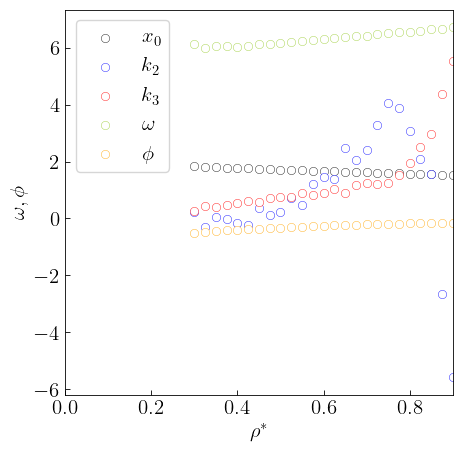

In [133]:
import numpy as np
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.scatter(rho[8:len(rho)], popt[:,5,0], facecolor="white", edgecolors="black", linewidth=0.3)
ax.scatter(rho[8:len(rho)], popt[:,5,1], facecolor="white", edgecolors="blue", linewidth=0.3)
ax.scatter(rho[8:len(rho)], popt[:,5,2], facecolor="white", edgecolors="red", linewidth=0.3)
ax.scatter(rho[8:len(rho)], popt[:,5,3], facecolor="white", edgecolors="yellowgreen", linewidth=0.3)
ax.scatter(rho[8:len(rho)], popt[:,5,4], facecolor="white", edgecolors="orange", linewidth=0.3)
ax.set_xlim([0.0, 0.9])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$\omega,\phi$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend([r"$x_{0}$", r"$k_{2}$", r"$k_{3}$", r"$\omega$", r"$\phi$"])
plt.savefig("enig3_tcf0_params.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [134]:
arrcolors = np.array(["black", "blue", "red", "yellowgreen", "orange", "purple", "cyan", "magenta"])
angles = np.array([r"$\theta=60^{\circ}$", r"$\theta=90^{\circ}$", r"$\theta=109.5^{\circ}$", r"$\theta=120^{\circ}$", r"$\theta=180^{\circ}$", "flexible"])

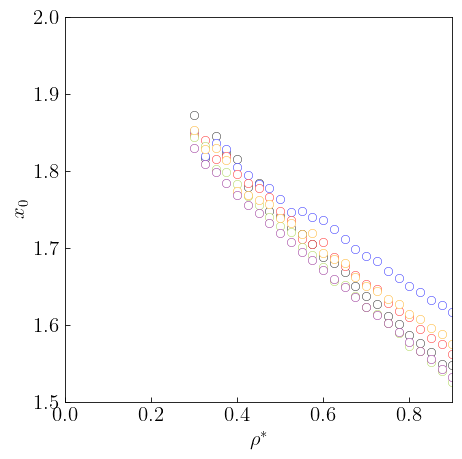

In [135]:
import numpy as np
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
for b in range(6):
    ax.scatter(rho[8:len(rho)], popt[:,b,0], facecolor="white", edgecolors=arrcolors[b], linewidth=0.3)
ax.set_xlim([0.0, 0.9])
ax.set_ylim([1.5, 2.0])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$x_{0}$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.savefig("enig3_tcf0_x0.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [136]:
p = 0
def linear(x, a):
    import math
    x = x*math.pi/6.0
    return 2.0+a*x

model = linear
init_guess = [-1.0]
params = np.zeros((6,5))
pfit = np.zeros((6,5,len(xfit)))
for b in range(6):
    x = rho[8:len(rho)]
    y = popt[:,b,p]
    params[b,p], _ = curve_fit(model, x, y, p0=init_guess)
    pfit[b,p,:] = model(xfit, params[b,p])

C:\Users\HP\AppData\Local\Temp\ipykernel_5000\93174104.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  params[b,p], _ = curve_fit(model, x, y, p0=init_guess)


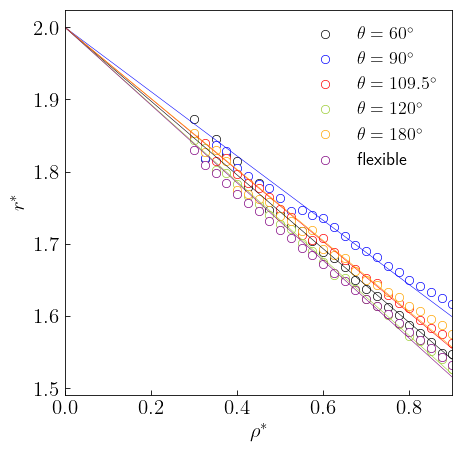

In [137]:
import numpy as np
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
for b in range(6):
    ax.scatter(rho[8:len(rho)], popt[:,b,p], facecolor="white", edgecolors=arrcolors[b], label=angles[b], linewidth=0.5)
    ax.plot(xfit, pfit[b,p,:], linestyle="solid", color=arrcolors[b], linewidth=0.4)
ax.set_xlim([0.0, 0.9])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$r^{\ast}$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend(frameon=False, fontsize=13)
plt.savefig("enig3_tcf0_r0.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [138]:
p = 1

def model(x, a, b):
    import math
    x = x*math.pi/6.0
    return a*x*np.exp(b*x)

init_guess = np.zeros(2)
params = np.zeros((6,5,len(init_guess)))
pfit = np.zeros((6,5,len(xfit)))
for b in range(6):
    x = rho[8:len(rho)]
    y = popt[:,b,p]
    params[b,p,:], _ = curve_fit(model, x, y, p0=init_guess)
    pfit[b,p,:] = model(xfit, *params[b,p,:])

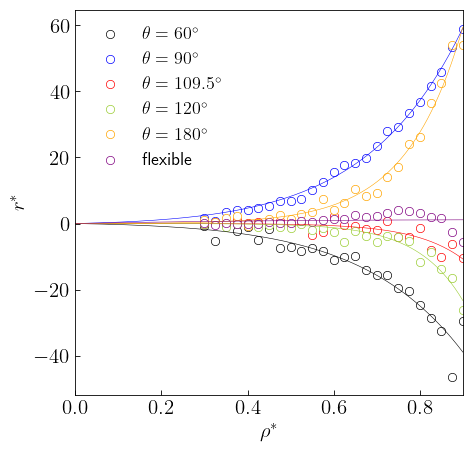

In [139]:
import numpy as np
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
for b in range(6):
    ax.scatter(rho[8:len(rho)], popt[:,b,p], facecolor="white", edgecolors=arrcolors[b], label=angles[b], linewidth=0.5)
    ax.plot(xfit, pfit[b,p,:], linestyle="solid", color=arrcolors[b], linewidth=0.4)
ax.set_xlim([0.0, 0.9])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$r^{\ast}$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend(frameon=False, fontsize=13)
plt.savefig("enig3_tcf0_k2.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [140]:
p = 2

def model(x, a, b):
    import math
    x = x*math.pi/6.0
    return a*x*np.exp(b*x)

init_guess = np.zeros(2)
params = np.zeros((6,5,len(init_guess)))
pfit = np.zeros((6,5,len(xfit)))
for b in range(6):
    x = rho[8:len(rho)]
    y = popt[:,b,p]
    params[b,p,:], _ = curve_fit(model, x, y, p0=init_guess)
    pfit[b,p,:] = model(xfit, *params[b,p,:])

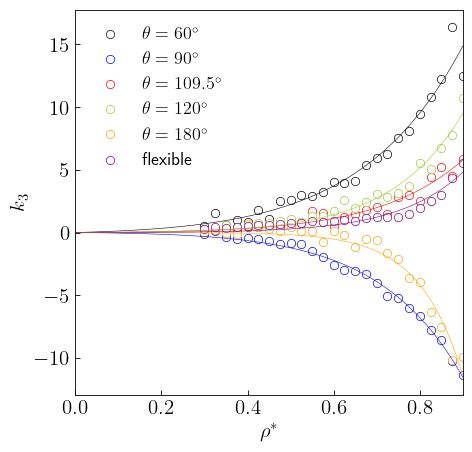

In [141]:
import numpy as np
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
for b in range(6):
    ax.scatter(rho[8:len(rho)], popt[:,b,p], facecolor="white", edgecolors=arrcolors[b], label=angles[b], linewidth=0.5)
    ax.plot(xfit, pfit[b,p,:], linestyle="solid", color=arrcolors[b], linewidth=0.4)
ax.set_xlim([0.0, 0.9])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$k_{3}$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend(frameon=False, fontsize=13)
plt.savefig("enig3_tcf0_k3.pdf", format="pdf", bbox_inches="tight")
plt.show()

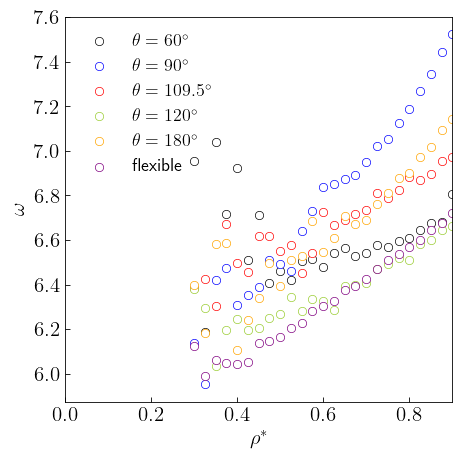

In [142]:
import numpy as np
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
for b in range(6):
    ax.scatter(rho[8:len(rho)], popt[:,b,3], facecolor="white", edgecolors=arrcolors[b], label=angles[b], linewidth=0.5)
ax.set_xlim([0.0, 0.9])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$\omega$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend(frameon=False, fontsize=13)
plt.savefig("enig3_tcf0_omega.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [143]:
# with minimum fixed
def f1(x, x0, k2, k3, rho, angle):
    ag3 = np.array([[-1.72984277,  1.57524637],
       [-2.7848363 ,  1.92823865],
       [-2.96129275,  2.42439139],
       [-2.93510074,  2.51225861],
       [-2.93180517,  2.44530674],
       [ 0.23561984,  0.09906896]])
    aag3 = ag3[angle]
    import math
    eta =  math.pi/6.0*rho
    if angle <= 4:
        g30 = (1.0+aag3[0]*eta+aag3[1]*eta**2)/(1.0-eta)**3*(g2cs(rho))**2
    else:
        g30 = (1.0+aag3[0]*eta+aag3[1]*eta**2)*(g2cs(rho))**2
    k1 = -x0*(3.0*x0*k3+2.0*k2)
    k0 = np.log(g30)-(k1+k2+k3)
    
    return np.exp(k0+k1*x+k2*x**2+k3*x**3)

def f2(x, x0, k2, k3, alpha, omg, rho, angle):
    
    g_min = f1(x0, x0, k2, k3, rho, angle)
    
    A = (g_min-1.0)*np.exp(alpha*x0)*(x0*np.cos(omg*x0)-(1.0+alpha*x0)/omg*np.sin(omg*x0))
    B = (g_min-1.0)*x0*np.exp(alpha*x0)/np.sin(omg*x0)-A/np.tan(omg*x0)
    
    return 1.0+1.0/x*np.exp(-alpha*x)*(A*np.cos(omg*x)+B*np.sin(omg*x))

def fit_g3(x, x0, k2, k3, alpha, omg, rho, angle):
    
    x = np.asarray(x)
    y = np.empty_like(x, dtype=float)

    mask = x <= x0

    y[mask] = f1(x[mask], x0, k2, k3, rho, angle)
    y[~mask] = f2(x[~mask], x0, k2, k3, alpha, omg, rho, angle)

    return y

In [144]:
indmin = 8
lower_bounds = [1.5, -np.inf, -np.inf, 0.0, 0.0]
upper_bounds = [2.0,  np.inf,  np.inf,  np.inf,  np.inf]
yfit = np.zeros((len(rho)-indmin,6,len(r)))
popt = np.zeros((len(rho)-indmin,6,5))
for i in range(indmin,len(rho)):
    rho_index = i
    print("We are processing rho* =", np.round(rho[rho_index],3))
    for j in range(6):
        ang_index = j
        x_data = data_tcf3[rho_index][:,0]        
        g_data = data_tcf3[rho_index][:,ang_index+1]
        mask = (x_data > 1.0) & (x_data < 3.0)
        x0 = x_data[mask][np.argmin(g_data[mask])]
        if i == indmin:
            init_val = [x0, 1.0, 1.0, 1.0, 5.0]
        else:
            init_val = popt[i-indmin-1,j]
        g30s = (tcf0_ex[rho_index]+1.0)*exrdf0[rho_index]**2
        g30_val = g30s[ang_index]
        popt[i-8,j,:], pcov = curve_fit(
            lambda x, x0, k2, k3, alpha, omg: fit_g3(x, x0, k2, k3, alpha, omg, rho[i], j),
            x_data[mask],
            g_data[mask],
            p0 = init_val,
            maxfev=50000,
            bounds = (lower_bounds, upper_bounds)
            )
        yfit[i-indmin,j,:] = fit_g3(r, *popt[i-indmin,j,:], rho[i], j)

We are processing rho* = 0.3
We are processing rho* = 0.325
We are processing rho* = 0.35
We are processing rho* = 0.375
We are processing rho* = 0.4
We are processing rho* = 0.425
We are processing rho* = 0.45
We are processing rho* = 0.475
We are processing rho* = 0.5
We are processing rho* = 0.525
We are processing rho* = 0.55
We are processing rho* = 0.575
We are processing rho* = 0.6
We are processing rho* = 0.625
We are processing rho* = 0.65
We are processing rho* = 0.675
We are processing rho* = 0.7
We are processing rho* = 0.725
We are processing rho* = 0.75
We are processing rho* = 0.775
We are processing rho* = 0.8
We are processing rho* = 0.825
We are processing rho* = 0.85
We are processing rho* = 0.875
We are processing rho* = 0.9


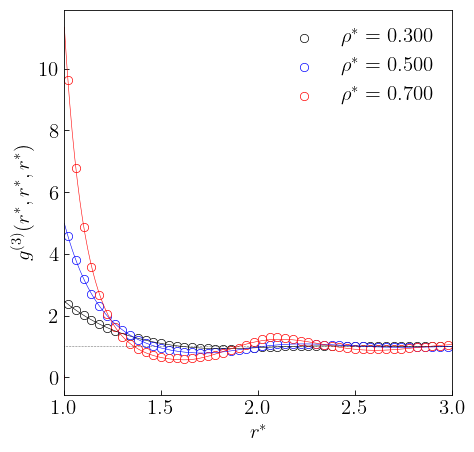

In [145]:
#flexible
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.scatter(data_tcf3[8][:,0], data_tcf3[8][:,6], facecolor="white", edgecolors="black", linewidth=0.5)
ax.scatter(data_tcf3[16][:,0], data_tcf3[16][:,6], facecolor="white", edgecolors="blue", linewidth=0.5)
ax.scatter(data_tcf3[24][:,0], data_tcf3[24][:,6], facecolor="white", edgecolors="red", linewidth=0.5)
ax.plot(r, yfit[0,5], linestyle="solid", color="black", linewidth=0.4)
ax.plot(r, yfit[8,5], linestyle="solid", color="blue", linewidth=0.4)
ax.plot(r, yfit[16,5], linestyle="solid", color="red", linewidth=0.4)
ax.axhline(y=1.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([1.0, 3.0])
ax.set_xlabel(r"$r^{\ast}$")
ax.set_ylabel(r"$g^{(3)}(r^{\ast},r^{\ast},r^{\ast})$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend([r"$\rho^{\ast}=0.300$", r"$\rho^{\ast}=0.500$", r"$\rho^{\ast}=0.700$"], frameon=False)
plt.savefig("enig3_tcf_%i_%.1f.pdf" % (Np, bang[5]), format="pdf", bbox_inches="tight")
plt.show()

In [146]:
p = 3
pfit = np.zeros((6,5,len(xfit)))
def model(x, a, b):
    import math
    x = x*math.pi/6.0
    return a*np.exp(b*x)

init_guess = np.zeros(2)
params = np.zeros((6,5,len(init_guess)))
for b in range(6):
    x = rho[8:len(rho)]
    y = popt[:,b,p]
    params[b,p,:], _ = curve_fit(model, x, y, p0=init_guess)
    pfit[b,p,:] = model(xfit, *params[b,p,:])

In [147]:
np.round(params[5,3,:],5)

array([ 7.20131, -6.15535])

In [148]:
p = 4

def model(x, a, b):
    import math
    x = x*math.pi/6.0
    return a+b*x

init_guess = np.zeros(2)
params = np.zeros((6,5,len(init_guess)))
for b in range(6):
    x = rho[8:len(rho)]
    y = popt[:,b,p]
    params[b,p,:], _ = curve_fit(model, x, y, p0=init_guess)
    pfit[b,p,:] = model(xfit, *params[b,p,:])

In [149]:
np.round(params[5,4,:],5)

array([5.51522, 2.44304])

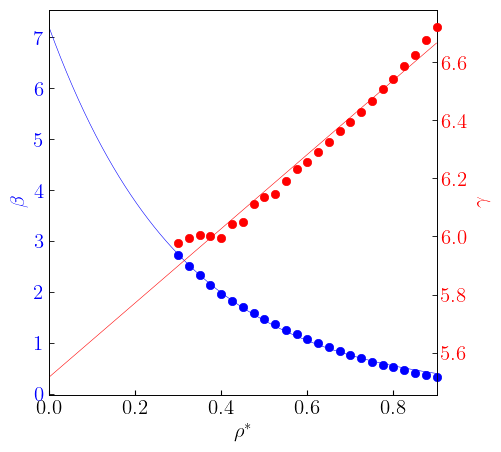

In [151]:
import numpy as np
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.scatter(rho[8:len(rho)], popt[:,5,3], facecolor="blue", edgecolors="blue", label=r"$\alpha$", linewidth=0.5, clip_on=False, zorder=10)
ax.plot(xfit, pfit[5,3,:], linestyle="solid", color="blue", linewidth=0.4)
ax.tick_params(width=0.6, direction='in', axis='y', labelcolor="blue")
ax.set_xlim([0.0, 0.9])
ax.set_ylabel(r"$\beta$", color="blue")
ax2 = ax.twinx()
ax2.tick_params(width=0.6, direction='in', axis='y', labelcolor="red")
ax2.scatter(rho[8:len(rho)], popt[:,5,4], facecolor="red", edgecolors="red", label=r"$\omega$", linewidth=0.5, clip_on=False, zorder=10)
ax2.plot(xfit, pfit[5,4,:], linestyle="solid", color="red", linewidth=0.4)
ax.set_xlabel(r"$\rho^{\ast}$")
ax2.set_ylabel(r"$\gamma$", color="red")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
    ax2.spines[axis].set_linewidth(0.6)
plt.savefig("enig3_tcf0_alpha_omg_flex.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [152]:
def f1(x, x0, k2, k3, rho, angle):
    ag3 = np.array([[-1.72984277,  1.57524637],
       [-2.7848363 ,  1.92823865],
       [-2.96129275,  2.42439139],
       [-2.93510074,  2.51225861],
       [-2.93180517,  2.44530674],
       [ 0.23561984,  0.09906896]])
    aag3 = ag3[angle]
    import math
    eta =  math.pi/6.0*rho
    if angle <= 4:
        g30 = (1.0+aag3[0]*eta+aag3[1]*eta**2)/(1.0-eta)**3*(g2cs(rho))**2
    else:
        g30 = (1.0+aag3[0]*eta+aag3[1]*eta**2)*(g2cs(rho))**2
    k1 = -x0*(3.0*x0*k3+2.0*k2)
    k0 = np.log(g30)-(k1+k2+k3)
    
    return np.exp(k0+k1*x+k2*x**2+k3*x**3)

def f2(x, x0, k2, k3, alpha, omg, rho, angle):
    import math
    g_min = f1(x0, x0, k2, k3, rho, angle)
    alpha = 7.20130871*np.exp(-6.15534664*math.pi/6.0*rho)
    omg = 5.51521887+2.44303807*math.pi/6.0*rho
    A = (g_min-1.0)*np.exp(alpha*x0)*(x0*np.cos(omg*x0)-(1.0+alpha*x0)/omg*np.sin(omg*x0))
    B = (g_min-1.0)*x0*np.exp(alpha*x0)/np.sin(omg*x0)-A/np.tan(omg*x0)
    
    return 1.0+1.0/x*np.exp(-alpha*x)*(A*np.cos(omg*x)+B*np.sin(omg*x))

def fit_g3(x, x0, k2, k3, alpha, omg, rho, angle):
    
    x = np.asarray(x)
    y = np.empty_like(x, dtype=float)

    mask = x <= x0

    y[mask] = f1(x[mask], x0, k2, k3, rho, angle)
    y[~mask] = f2(x[~mask], x0, k2, k3, alpha, omg, rho, angle)

    return y

In [153]:
indmin = 8
lower_bounds = [1.5, -np.inf, -np.inf, 0.0, 0.0]
upper_bounds = [2.0,  np.inf,  np.inf,  np.inf,  np.inf]
yfit = np.zeros((len(rho)-indmin,6,len(r)))
popt = np.zeros((len(rho)-indmin,6,5))
for i in range(indmin,len(rho)):
    rho_index = i
    print("We are processing rho* =", np.round(rho[rho_index],3))
    for j in range(6):
        ang_index = j
        x_data = data_tcf3[rho_index][:,0]        
        g_data = data_tcf3[rho_index][:,ang_index+1]
        mask = (x_data > 1.0) & (x_data < 3.0)
        x0 = x_data[mask][np.argmin(g_data[mask])]
        if i == indmin:
            init_val = [x0, 1.0, 1.0, 1.0, 5.0]
        else:
            init_val = popt[i-indmin-1,j]
        g30s = (tcf0_ex[rho_index]+1.0)*exrdf0[rho_index]**2
        g30_val = g30s[ang_index]
        popt[i-8,j,:], pcov = curve_fit(
            lambda x, x0, k2, k3, alpha, omg: fit_g3(x, x0, k2, k3, alpha, omg, rho[i], j),
            x_data[mask],
            g_data[mask],
            p0 = init_val,
            maxfev=100000,
            bounds = (lower_bounds, upper_bounds)
            )
        yfit[i-indmin,j,:] = fit_g3(r, *popt[i-indmin,j,:], rho[i], j)

We are processing rho* = 0.3
We are processing rho* = 0.325
We are processing rho* = 0.35
We are processing rho* = 0.375
We are processing rho* = 0.4
We are processing rho* = 0.425
We are processing rho* = 0.45
We are processing rho* = 0.475
We are processing rho* = 0.5
We are processing rho* = 0.525
We are processing rho* = 0.55
We are processing rho* = 0.575
We are processing rho* = 0.6
We are processing rho* = 0.625
We are processing rho* = 0.65
We are processing rho* = 0.675
We are processing rho* = 0.7
We are processing rho* = 0.725
We are processing rho* = 0.75
We are processing rho* = 0.775
We are processing rho* = 0.8
We are processing rho* = 0.825
We are processing rho* = 0.85
We are processing rho* = 0.875
We are processing rho* = 0.9


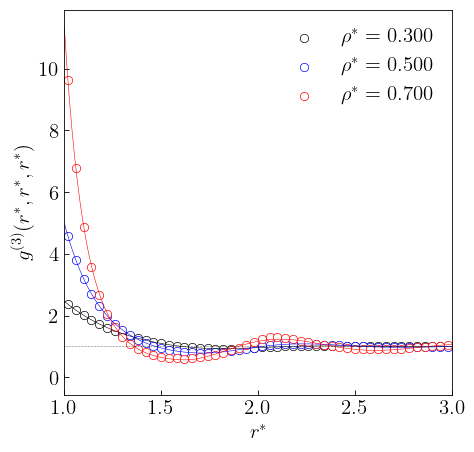

In [154]:
#flexible
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.scatter(data_tcf3[8][:,0], data_tcf3[8][:,6], facecolor="white", edgecolors="black", linewidth=0.5)
ax.scatter(data_tcf3[16][:,0], data_tcf3[16][:,6], facecolor="white", edgecolors="blue", linewidth=0.5)
ax.scatter(data_tcf3[24][:,0], data_tcf3[24][:,6], facecolor="white", edgecolors="red", linewidth=0.5)
ax.plot(r, yfit[0,5], linestyle="solid", color="black", linewidth=0.4)
ax.plot(r, yfit[8,5], linestyle="solid", color="blue", linewidth=0.4)
ax.plot(r, yfit[16,5], linestyle="solid", color="red", linewidth=0.4)
ax.axhline(y=1.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([1.0, 3.0])
ax.set_xlabel(r"$r^{\ast}$")
ax.set_ylabel(r"$g^{(3)}(r^{\ast},r^{\ast},r^{\ast})$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend([r"$\rho^{\ast}=0.300$", r"$\rho^{\ast}=0.500$", r"$\rho^{\ast}=0.700$"], frameon=False)
plt.show()

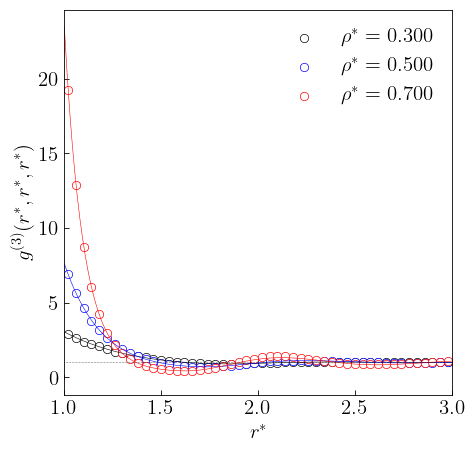

In [155]:
#60
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.scatter(data_tcf3[8][:,0], data_tcf3[8][:,1], facecolor="white", edgecolors="black", linewidth=0.5)
ax.scatter(data_tcf3[16][:,0], data_tcf3[16][:,1], facecolor="white", edgecolors="blue", linewidth=0.5)
ax.scatter(data_tcf3[24][:,0], data_tcf3[24][:,1], facecolor="white", edgecolors="red", linewidth=0.5)
ax.plot(r, yfit[0,0], linestyle="solid", color="black", linewidth=0.4)
ax.plot(r, yfit[8,0], linestyle="solid", color="blue", linewidth=0.4)
ax.plot(r, yfit[16,0], linestyle="solid", color="red", linewidth=0.4)
ax.axhline(y=1.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([1.0, 3.0])
ax.set_xlabel(r"$r^{\ast}$")
ax.set_ylabel(r"$g^{(3)}(r^{\ast},r^{\ast},r^{\ast})$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend([r"$\rho^{\ast}=0.300$", r"$\rho^{\ast}=0.500$", r"$\rho^{\ast}=0.700$"], frameon=False)
plt.savefig("enig3_tcf_%i_%.1f.pdf" % (Np, bang[0]), format="pdf", bbox_inches="tight")
plt.show()

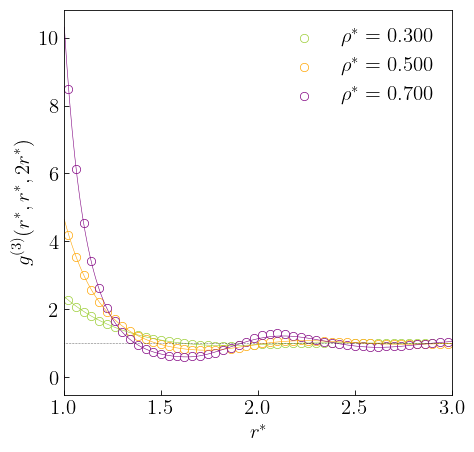

In [156]:
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
ax.scatter(data_tcf3[8][:,0], data_tcf3[8][:,5], facecolor="white", edgecolors="yellowgreen", linewidth=0.5)
ax.scatter(data_tcf3[16][:,0], data_tcf3[16][:,5], facecolor="white", edgecolors="orange", linewidth=0.5)
ax.scatter(data_tcf3[24][:,0], data_tcf3[24][:,5], facecolor="white", edgecolors="purple", linewidth=0.5)
ax.plot(r, yfit[0,4], linestyle="solid", color="yellowgreen", linewidth=0.4)
ax.plot(r, yfit[8,4], linestyle="solid", color="orange", linewidth=0.4)
ax.plot(r, yfit[16,4], linestyle="solid", color="purple", linewidth=0.4)
ax.axhline(y=1.0, color="black", linestyle="dotted", linewidth=0.4)
ax.set_xlim([1.0, 3.0])
ax.set_xlabel(r"$r^{\ast}$")
ax.set_ylabel(r"$g^{(3)}(r^{\ast},r^{\ast},2r^{\ast})$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend([r"$\rho^{\ast}=0.300$", r"$\rho^{\ast}=0.500$", r"$\rho^{\ast}=0.700$"], frameon=False)
plt.savefig("enig3_tcf_%i_%.1f.pdf" % (Np, bang[4]), format="pdf", bbox_inches="tight")
plt.show()

In [157]:
p = 0
def linear(x, a, b):
    import math
    x = x*math.pi/6.0
    return a+b*x

model = linear
init_guess = [2.0, -1.0]
params = np.zeros((6,5,len(init_guess)))
pfit = np.zeros((6,5,len(xfit)))
for b in range(6):
    x = rho[8:len(rho)]
    y = popt[:,b,p]
    params[b,p,:], _ = curve_fit(model, x, y, p0=init_guess)
    print(np.round(params[b,p,:],5))
    pfit[b,p,:] = model(xfit, *params[b,p,:])

[ 1.98952 -0.97616]
[ 1.98271 -0.89851]
[ 1.98171 -0.93633]
[ 1.98721 -0.98734]
[ 1.97482 -0.91958]
[ 1.96202 -0.9272 ]


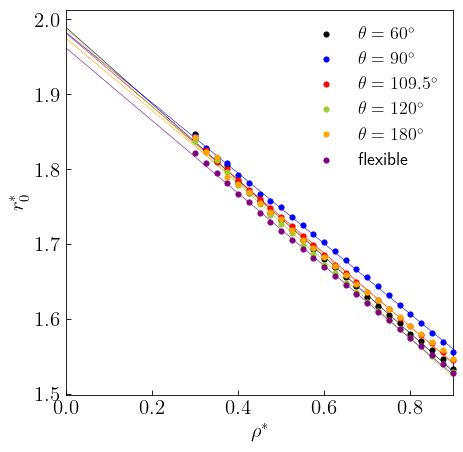

In [158]:
import numpy as np
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
for b in range(6):
    ax.scatter(rho[8:len(rho)], popt[:,b,p], facecolor=arrcolors[b], edgecolors=arrcolors[b], label=angles[b], linewidth=0.5, s=15, clip_on=False, zorder=10)
    ax.plot(xfit, pfit[b,p,:], linestyle="solid", color=arrcolors[b], linewidth=0.4)
ax.set_xlim([0.0, 0.9])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$r^{\ast}_{0}$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend(frameon=False, fontsize=13)
plt.savefig("enig3_tcf0_r0.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [159]:
p = 1

def model_rig(x, a, b, c, d):
    import math
    x = x*math.pi/6.0
    return x*(a*x+b*x**2)/(1.0+c*x+d*x**2)

def model_flex(x, a, b, c, d, e, f):
    import math
    x = x*math.pi/6.0
    return x*(a*x+b*x**2+c*x**3)/(1.0+d*x+e*x**2+f*x**3)
    
init_guess_rig = np.zeros(4)
init_guess_flex = np.zeros(6)
params_rig = np.zeros((6,5,len(init_guess_rig)))
params_flex = np.zeros((6,5,len(init_guess_flex)))
pfit = np.zeros((6,5,len(xfit)))
for b in range(6):
    x = rho[8:len(rho)]
    y = popt[:,b,p]
    if b < 5:
        model = model_rig
        params_rig[b,p,:], _ = curve_fit(model, x, y, p0=init_guess_rig)
        params = params_rig[b,p,:]
    else:
        model = model_flex
        params_flex[b,p], _ = curve_fit(model, x, y, p0=init_guess_flex)
        params = params_flex[b,p]
    print(np.round(params,5))
    pfit[b,p,:] = model(xfit, *params)

[-130.49532   95.69752    0.92979   -5.01732]
[ 33.14936 -13.86127  -3.48147   3.53661]
[  2.79579 -25.6997   -3.66908   3.73112]
[  0.30718 -13.07973  -4.20113   4.77423]
[ 6.2028  -3.96972 -3.89212  3.84756]
[ -14.85919   84.98827 -118.00605   -5.35355   10.246     -6.95473]


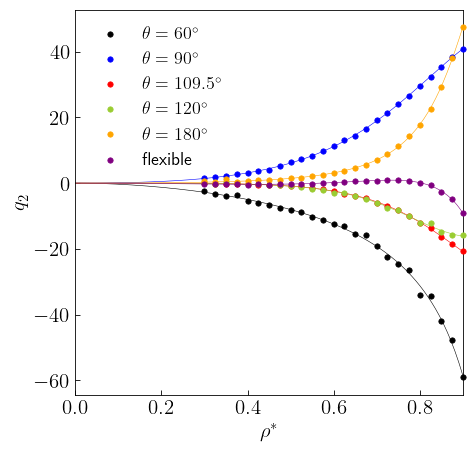

In [160]:
import numpy as np
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
for b in range(6):
    ax.scatter(rho[8:len(rho)], popt[:,b,p], facecolor=arrcolors[b], edgecolors=arrcolors[b], label=angles[b], linewidth=0.5,  s=15, clip_on=False, zorder=10)
    ax.plot(xfit, pfit[b,p,:], linestyle="solid", color=arrcolors[b], linewidth=0.4)
ax.set_xlim([0.0, 0.9])
#ax.set_ylim([-10, 10])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$q_{2}$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend(frameon=False, fontsize=13)
plt.savefig("enig3_tcf0_k2.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [161]:
p = 2

def model_rig(x, a, b, c, d):
    import math
    x = x*math.pi/6.0
    return x*(a*x+b*x**2)/(1.0+c*x+d*x**2)

def model_flex(x, a, b, c, d, e, f):
    import math
    x = x*math.pi/6.0
    return x*(a*x+b*x**2+c*x**3)/(1.0+d*x+e*x**2+f*x**3)
    
init_guess_rig = np.zeros(4)
init_guess_flex = np.zeros(6)
params_rig = np.zeros((6,5,len(init_guess_rig)))
params_flex = np.zeros((6,5,len(init_guess_flex)))
pfit = np.zeros((6,5,len(xfit)))
for b in range(6):
    x = rho[8:len(rho)]
    y = popt[:,b,p]
    if b < 5:
        model = model_rig
        params_rig[b,p,:], _ = curve_fit(model, x, y, p0=init_guess_rig)
        params = params_rig[b,p,:]
    else:
        model = model_flex
        params_flex[b,p], _ = curve_fit(model, x, y, p0=init_guess_flex)
        params = params_flex[b,p]
    print(np.round(params,5))
    pfit[b,p,:] = model(xfit, *params)

[ 43.85726 -12.23017   1.46187  -5.70867]
[  1.55524 -17.39042  -3.77133   4.48887]
[  6.64855 -11.3585   -3.71254   3.52468]
[  6.53067 -10.78094  -3.80705   3.7548 ]
[  6.11972 -16.66338  -3.59213   3.33282]
[ 17.73219 -73.81478  83.64056  -3.24229   2.41324   0.42137]


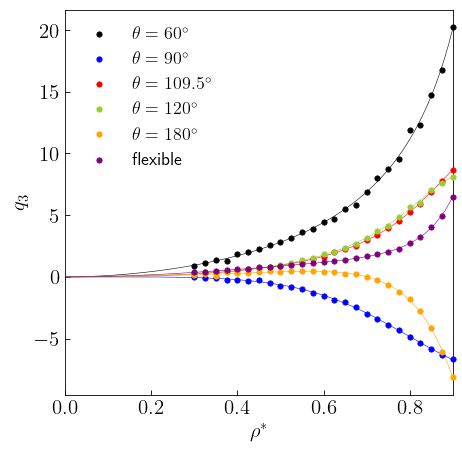

In [162]:
import numpy as np
plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(5,5))
ax.tick_params(direction='in')
for b in range(6):
    ax.scatter(rho[8:len(rho)], popt[:,b,p], facecolor=arrcolors[b], edgecolors=arrcolors[b], label=angles[b], linewidth=0.5, s=15, clip_on=False, zorder=10)
    ax.plot(xfit, pfit[b,p,:], linestyle="solid", color=arrcolors[b], linewidth=0.4)
ax.set_xlim([0.0, 0.9])
ax.set_xlabel(r"$\rho^{\ast}$")
ax.set_ylabel(r"$q_{3}$")
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.6)
ax.tick_params(width=0.6)
plt.legend(frameon=False, fontsize=13)
plt.savefig("enig3_tcf0_k3.pdf", format="pdf", bbox_inches="tight")
plt.show()